In [1]:
!pip install tensorflow

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

# Read the Excel file
# Replace 'your_file.xlsx' with your actual Excel file name
df = pd.read_excel('/content/drive/MyDrive/SOP_Twin/corrected_data.xlsx')

# Get all column names
columns = df.columns.tolist()

# Separate voltage and current columns
voltage_columns = columns[::2]  # Every even indexed column (0, 2, 4, ...)
current_columns = columns[1::2]  # Every odd indexed column (1, 3, 5, ...)

# Create new dataframe with renamed columns
new_df = pd.DataFrame()

# Add voltage columns with renamed headers
for i, col in enumerate(current_columns):
    new_df[f'Current_{i+1}'] = df[col]



# Display first few rows of the new dataframe
print(new_df.head())

   Current_1  Current_2  Current_3  Current_4  Current_5  Current_6  \
0   0.166782   0.148789   0.148789   0.279302   0.251573   0.251573   
1   0.316510   0.281952   0.281952   0.528848   0.476225   0.476225   
2   0.466090   0.415027   0.415027   0.778146   0.700691   0.700691   
3   0.615520   0.548013   0.548013   1.027195   0.924970   0.924970   
4   0.764801   0.680911   0.680911   1.275995   1.149063   1.149063   

   Current_7  Current_8  Current_9  Current_10  ...  Current_23  Current_24  \
0   0.071762   0.066991   0.080350    0.111517  ...    0.076913    0.076913   
1   0.135998   0.126946   0.152289    0.211408  ...    0.145615    0.145615   
2   0.200211   0.186882   0.224200    0.311243  ...    0.214295    0.214295   
3   0.264401   0.246798   0.296082    0.411023  ...    0.282954    0.282954   
4   0.328569   0.306695   0.367935    0.510748  ...    0.351592    0.351592   

   Current_25  Current_26  Current_27  Current_28  Current_29  Current_30  \
0    0.188956    0.11

In [4]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def prepare_sequences(df, n_steps=100):
    """
    Prepare sequences for time series prediction

    Args:
        df: DataFrame with voltage columns
        n_steps: Number of time steps to use for prediction

    Returns:
        X: Input sequences with shape (samples, time_steps, features)
        series_ids: Series identifiers for each sequence
        y: Target values
    """
    X, series_ids, y = [], [], []
    voltage_cols = [col for col in df.columns if 'Current_' in col]

    for series_idx, col in enumerate(voltage_cols):
        series_data = df[col].values

        # Create sequences for this series
        for j in range(len(series_data) - n_steps):
            X.append(series_data[j:j+n_steps])
            series_ids.append(series_idx)
            y.append(series_data[j+n_steps])

    return np.array(X), np.array(series_ids), np.array(y)

# Parameters
n_steps = 100  # Number of time steps in each sequence
test_size = 0.2  # Percentage of data to use for testing

# Prepare sequences
X, series_ids, y = prepare_sequences(new_df, n_steps)
X = X.reshape((X.shape[0], X.shape[1], 1))  # Reshape for LSTM (samples, timesteps, features)

# Create train-test split - IMPORTANT: For time series, we shouldn't shuffle!
# Split by series to keep temporal order
unique_series = np.unique(series_ids)
train_series = unique_series[:int(len(unique_series)*(1-test_size))]
test_series = unique_series[int(len(unique_series)*(1-test_size)):]

train_mask = np.isin(series_ids, train_series)
test_mask = np.isin(series_ids, test_series)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
series_ids_train, series_ids_test = series_ids[train_mask], series_ids[test_mask]

# Scale data - scale each series individually
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# For training data
X_train_scaled = np.zeros_like(X_train)
y_train_scaled = np.zeros_like(y_train)

for series_id in train_series:
    mask = (series_ids_train == series_id)
    # Scale X
    X_train_scaled[mask] = scaler_X.fit_transform(X_train[mask].reshape(-1, 1)).reshape(X_train[mask].shape)
    # Scale y
    y_train_scaled[mask] = scaler_y.fit_transform(y_train[mask].reshape(-1, 1)).flatten()

# For test data (use the same scalers from training)
X_test_scaled = np.zeros_like(X_test)
y_test_scaled = np.zeros_like(y_test)

for series_id in test_series:
    mask = (series_ids_test == series_id)
    # Scale X
    X_test_scaled[mask] = scaler_X.transform(X_test[mask].reshape(-1, 1)).reshape(X_test[mask].shape)
    # Scale y
    y_test_scaled[mask] = scaler_y.transform(y_test[mask].reshape(-1, 1)).flatten()

print(f"Training shapes - X: {X_train_scaled.shape}, y: {y_train_scaled.shape}")
print(f"Test shapes - X: {X_test_scaled.shape}, y: {y_test_scaled.shape}")

Training shapes - X: (247500, 100, 1), y: (247500,)
Test shapes - X: (69300, 100, 1), y: (69300,)


Original Target Data Range: [9.769, 63.205]
Scaled Target Data Range: [-0.056, 0.630]


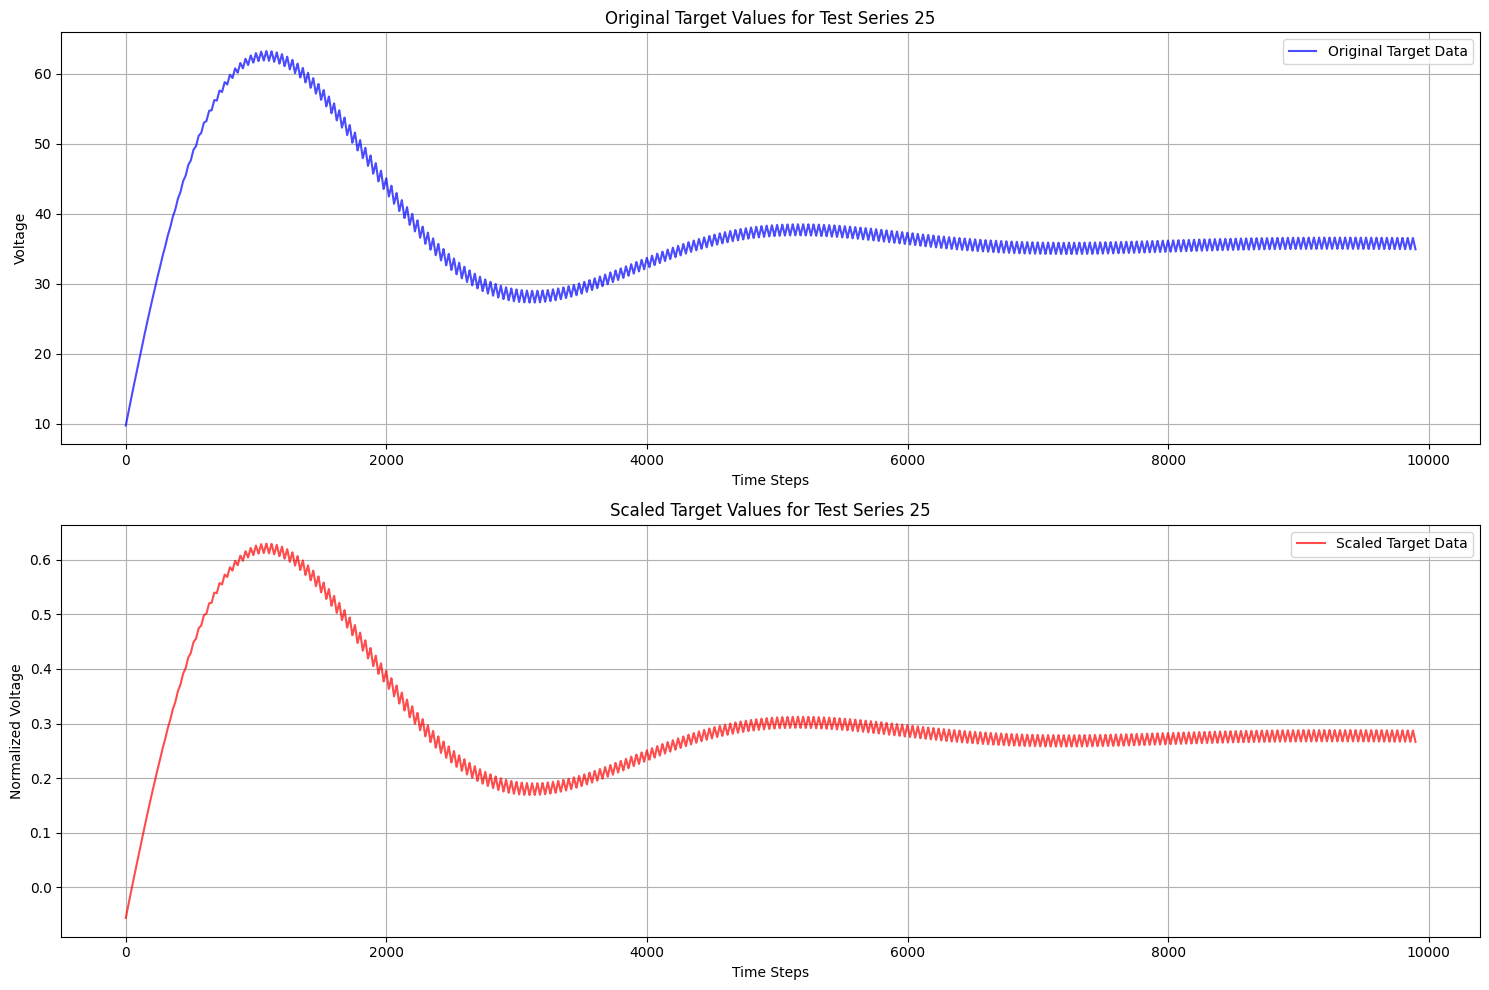

In [5]:
# Select a series ID from test_series
import matplotlib.pyplot as plt

series_id = test_series[0]  # Taking first test series

# Get masks for this series
test_mask_series = (series_ids_test == series_id)

# Get original and scaled target values
original_y = y_test[test_mask_series]
scaled_y = y_test_scaled[test_mask_series]

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Plot original target data
ax1.plot(original_y, label='Original Target Data', color='blue', alpha=0.7)
ax1.set_title(f'Original Target Values for Test Series {series_id}')
ax1.set_xlabel('Time Steps')
ax1.set_ylabel('Current')
ax1.grid(True)
ax1.legend()

# Plot scaled target data
ax2.plot(scaled_y, label='Scaled Target Data', color='red', alpha=0.7)
ax2.set_title(f'Scaled Target Values for Test Series {series_id}')
ax2.set_xlabel('Time Steps')
ax2.set_ylabel('Normalized Current')
ax2.grid(True)
ax2.legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Print statistics
print(f"Original Target Data Range: [{original_y.min():.3f}, {original_y.max():.3f}]")
print(f"Scaled Target Data Range: [{scaled_y.min():.3f}, {scaled_y.max():.3f}]")

plt.show()

In [6]:
def build_pooled_model(n_steps, n_features, n_series):
    """
    Build a pooled neural network model with series identifiers

    Args:
        n_steps: Number of time steps in input sequences
        n_features: Number of features per time step
        n_series: Number of unique series (voltage columns)

    Returns:
        model: Compiled Keras model
    """
    # Input layers
    time_series_input = Input(shape=(n_steps, n_features), name='time_series_input')
    series_id_input = Input(shape=(1,), name='series_id_input')

    # Embed the series identifier
    embedding_dim = min(5, (n_series + 1) // 2)  # Rule of thumb for embedding dimension
    series_embedding = Embedding(input_dim=n_series, output_dim=embedding_dim)(series_id_input)
    series_embedding = Dense(embedding_dim)(series_embedding)
    series_embedding = Dropout(0.2)(series_embedding)

    # Process time series with LSTM
    lstm_out = LSTM(50, return_sequences=False)(time_series_input)
    lstm_out = Dropout(0.2)(lstm_out)

    # Flatten embedding before concatenation
    series_embedding_flat = Dense(embedding_dim, activation='relu')(series_embedding[:, 0, :])

    # Combine features
    concatenated = Concatenate()([lstm_out, series_embedding_flat])

    # Output layer
    output = Dense(1)(concatenated)

    # Define model
    model = Model(inputs=[time_series_input, series_id_input], outputs=output)

    # Compile model
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    return model

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Concatenate, Dropout
n_steps = 100  # Number of time steps to use for prediction
n_features = 1  # Each sequence contains one feature (the voltage value)

Epoch 1/5
6187/6188 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0058 - mae: 0.0432

6188/6188 ━━━━━━━━━━━━━━━━━━━━ 245s 39ms/step - loss: 0.0058 - mae: 0.0431 - val_loss: 0.0014 - val_mae: 0.0340
Epoch 2/5
6187/6188 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 5.4402e-04 - mae: 0.0168

6188/6188 ━━━━━━━━━━━━━━━━━━━━ 243s 39ms/step - loss: 5.4402e-04 - mae: 0.0168 - val_loss: 6.8179e-04 - val_mae: 0.0243
Epoch 3/5
6188/6188 ━━━━━━━━━━━━━━━━━━━━ 262s 39ms/step - loss: 4.9450e-04 - mae: 0.0159 - val_loss: 7.4065e-04 - val_mae: 0.0238
Epoch 4/5
6187/6188 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 4.8346e-04 - mae: 0.0157

6188/6188 ━━━━━━━━━━━━━━━━━━━━ 262s 39ms/step - loss: 4.8346e-04 - mae: 0.0157 - val_loss: 3.3880e-04 - val_mae: 0.0163
Epoch 5/5
6188/6188 ━━━━━━━━━━━━━━━━━━━━ 262s 39ms/step - loss: 4.7560e-04 - mae: 0.0155 - val_loss: 4.4289e-04 - val_mae: 0.0189

Test Loss (MSE): 0.0000
Test MAE: 0.0049
2166/2166 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step


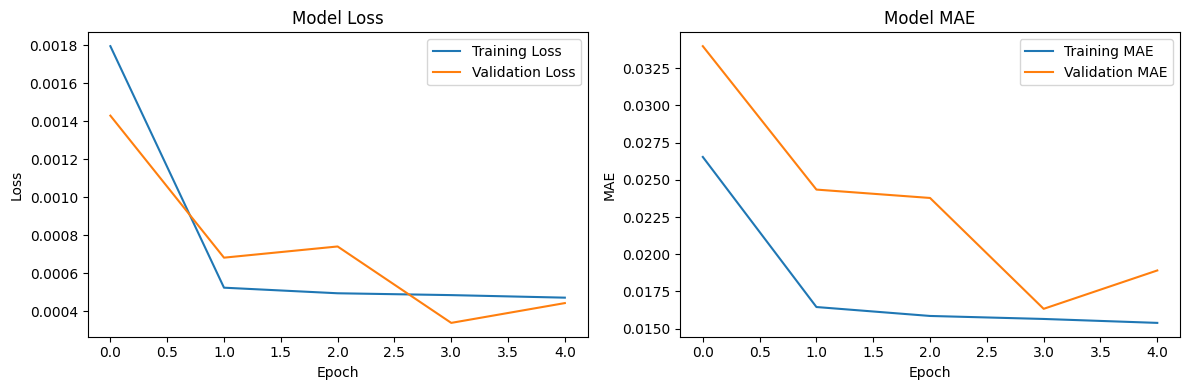

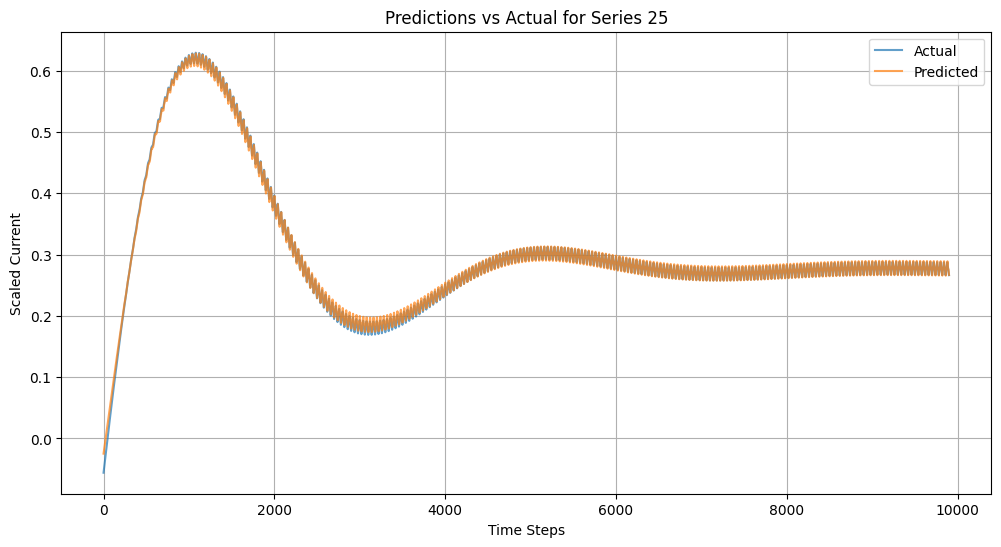

In [8]:
# Import required libraries
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Concatenate, Dropout
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Get dimensions for model
n_steps = 100
n_features = 1
n_series = len(np.unique(series_ids))

# Build the model using the function you defined
model = build_pooled_model(n_steps, n_features, n_series)

# Prepare inputs for training
train_series_ids = series_ids_train.reshape(-1, 1)
test_series_ids = series_ids_test.reshape(-1, 1)

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True
)

# Train the model
history = model.fit(
    [X_train_scaled, train_series_ids],  # Input data
    y_train_scaled,                       # Target data
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Evaluate the model
test_loss = model.evaluate(
    [X_test_scaled, test_series_ids],
    y_test_scaled,
    verbose=0
)

print(f'\nTest Loss (MSE): {test_loss[0]:.4f}')
print(f'Test MAE: {test_loss[1]:.4f}')

# Make predictions
y_pred_scaled = model.predict([X_test_scaled, test_series_ids])

# Visualize training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

# Plot predictions vs actual for one series
test_series_id = test_series[0]
series_mask = (series_ids_test == test_series_id)

plt.figure(figsize=(12, 6))
plt.plot(y_test_scaled[series_mask], label='Actual', alpha=0.7)
plt.plot(y_pred_scaled[series_mask], label='Predicted', alpha=0.7)
plt.title(f'Predictions vs Actual for Series {test_series_id}')
plt.xlabel('Time Steps')
plt.ylabel('Scaled Current')
plt.legend()
plt.grid(True)
plt.show()

Scaled Values Range:
Actual: [-0.056, 0.630]
Predicted: [-0.025, 0.628]

Original Values Range:
Actual: [9.769, 63.205]
Predicted: [12.194, 63.113]


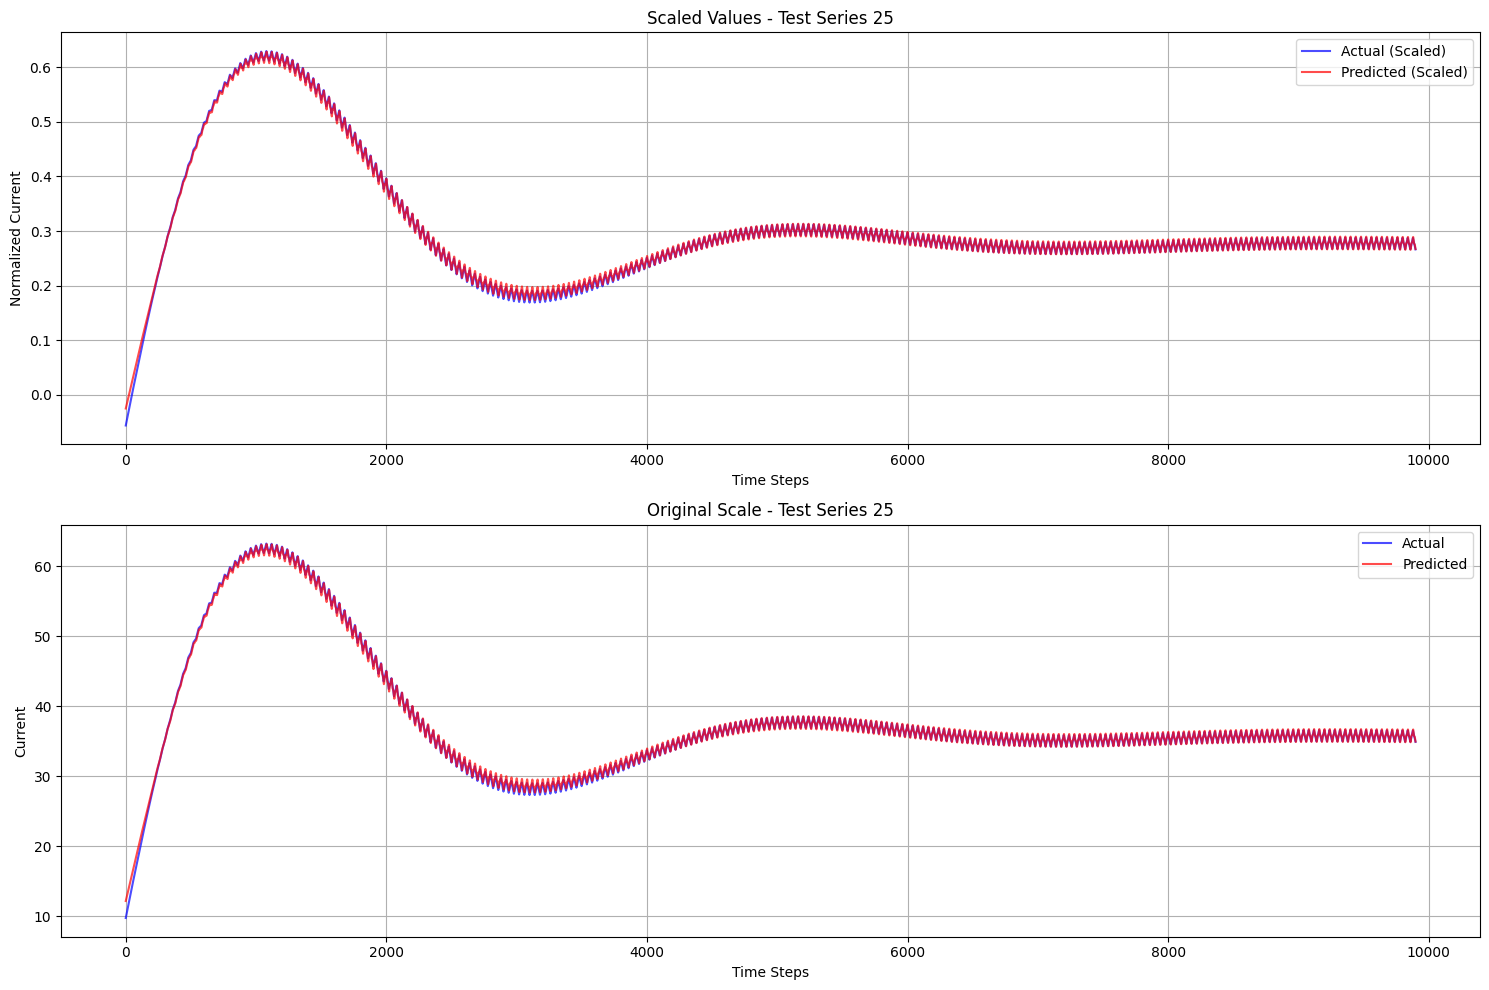

In [9]:
# Get a specific test series
test_series_id = test_series[0]
series_mask = (series_ids_test == test_series_id)

# Get the scaled predictions and actual values
scaled_actual = y_test_scaled[series_mask]
scaled_pred = y_pred_scaled[series_mask]

# Inverse transform to get original scale
original_actual = scaler_y.inverse_transform(scaled_actual.reshape(-1, 1)).flatten()
original_pred = scaler_y.inverse_transform(scaled_pred.reshape(-1, 1)).flatten()

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Plot scaled values
ax1.plot(scaled_actual, label='Actual (Scaled)', color='blue', alpha=0.7)
ax1.plot(scaled_pred, label='Predicted (Scaled)', color='red', alpha=0.7)
ax1.set_title(f'Scaled Values - Test Series {test_series_id}')
ax1.set_xlabel('Time Steps')
ax1.set_ylabel('Normalized Current')
ax1.grid(True)
ax1.legend()

# Plot original values
ax2.plot(original_actual, label='Actual', color='blue', alpha=0.7)
ax2.plot(original_pred, label='Predicted', color='red', alpha=0.7)
ax2.set_title(f'Original Scale - Test Series {test_series_id}')
ax2.set_xlabel('Time Steps')
ax2.set_ylabel('Current')
ax2.grid(True)
ax2.legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Print some statistics
print("Scaled Values Range:")
print(f"Actual: [{scaled_actual.min():.3f}, {scaled_actual.max():.3f}]")
print(f"Predicted: [{scaled_pred.min():.3f}, {scaled_pred.max():.3f}]")
print("\nOriginal Values Range:")
print(f"Actual: [{original_actual.min():.3f}, {original_actual.max():.3f}]")
print(f"Predicted: [{original_pred.min():.3f}, {original_pred.max():.3f}]")

plt.show()


Series 25 Statistics (Index 4000 to 4199):
Scaled Values Range:
Actual: [0.234, 0.270]
Predicted: [0.235, 0.271]
Original Values Range:
Actual: [32.356, 35.148]
Predicted: [32.431, 35.226]

Series 26 Statistics (Index 4000 to 4199):
Scaled Values Range:
Actual: [0.266, 0.306]
Predicted: [0.270, 0.308]
Original Values Range:
Actual: [34.899, 38.020]
Predicted: [35.205, 38.163]

Series 27 Statistics (Index 4000 to 4199):
Scaled Values Range:
Actual: [0.538, 0.550]
Predicted: [0.548, 0.559]
Original Values Range:
Actual: [56.105, 56.975]
Predicted: [56.822, 57.690]

Series 28 Statistics (Index 4000 to 4199):
Scaled Values Range:
Actual: [0.639, 0.662]
Predicted: [0.636, 0.661]
Original Values Range:
Actual: [63.953, 65.748]
Predicted: [63.734, 65.686]

Series 29 Statistics (Index 4000 to 4199):
Scaled Values Range:
Actual: [0.517, 0.541]
Predicted: [0.521, 0.545]
Original Values Range:
Actual: [54.455, 56.302]
Predicted: [54.747, 56.607]

Series 30 Statistics (Index 4000 to 4199):
Scaled

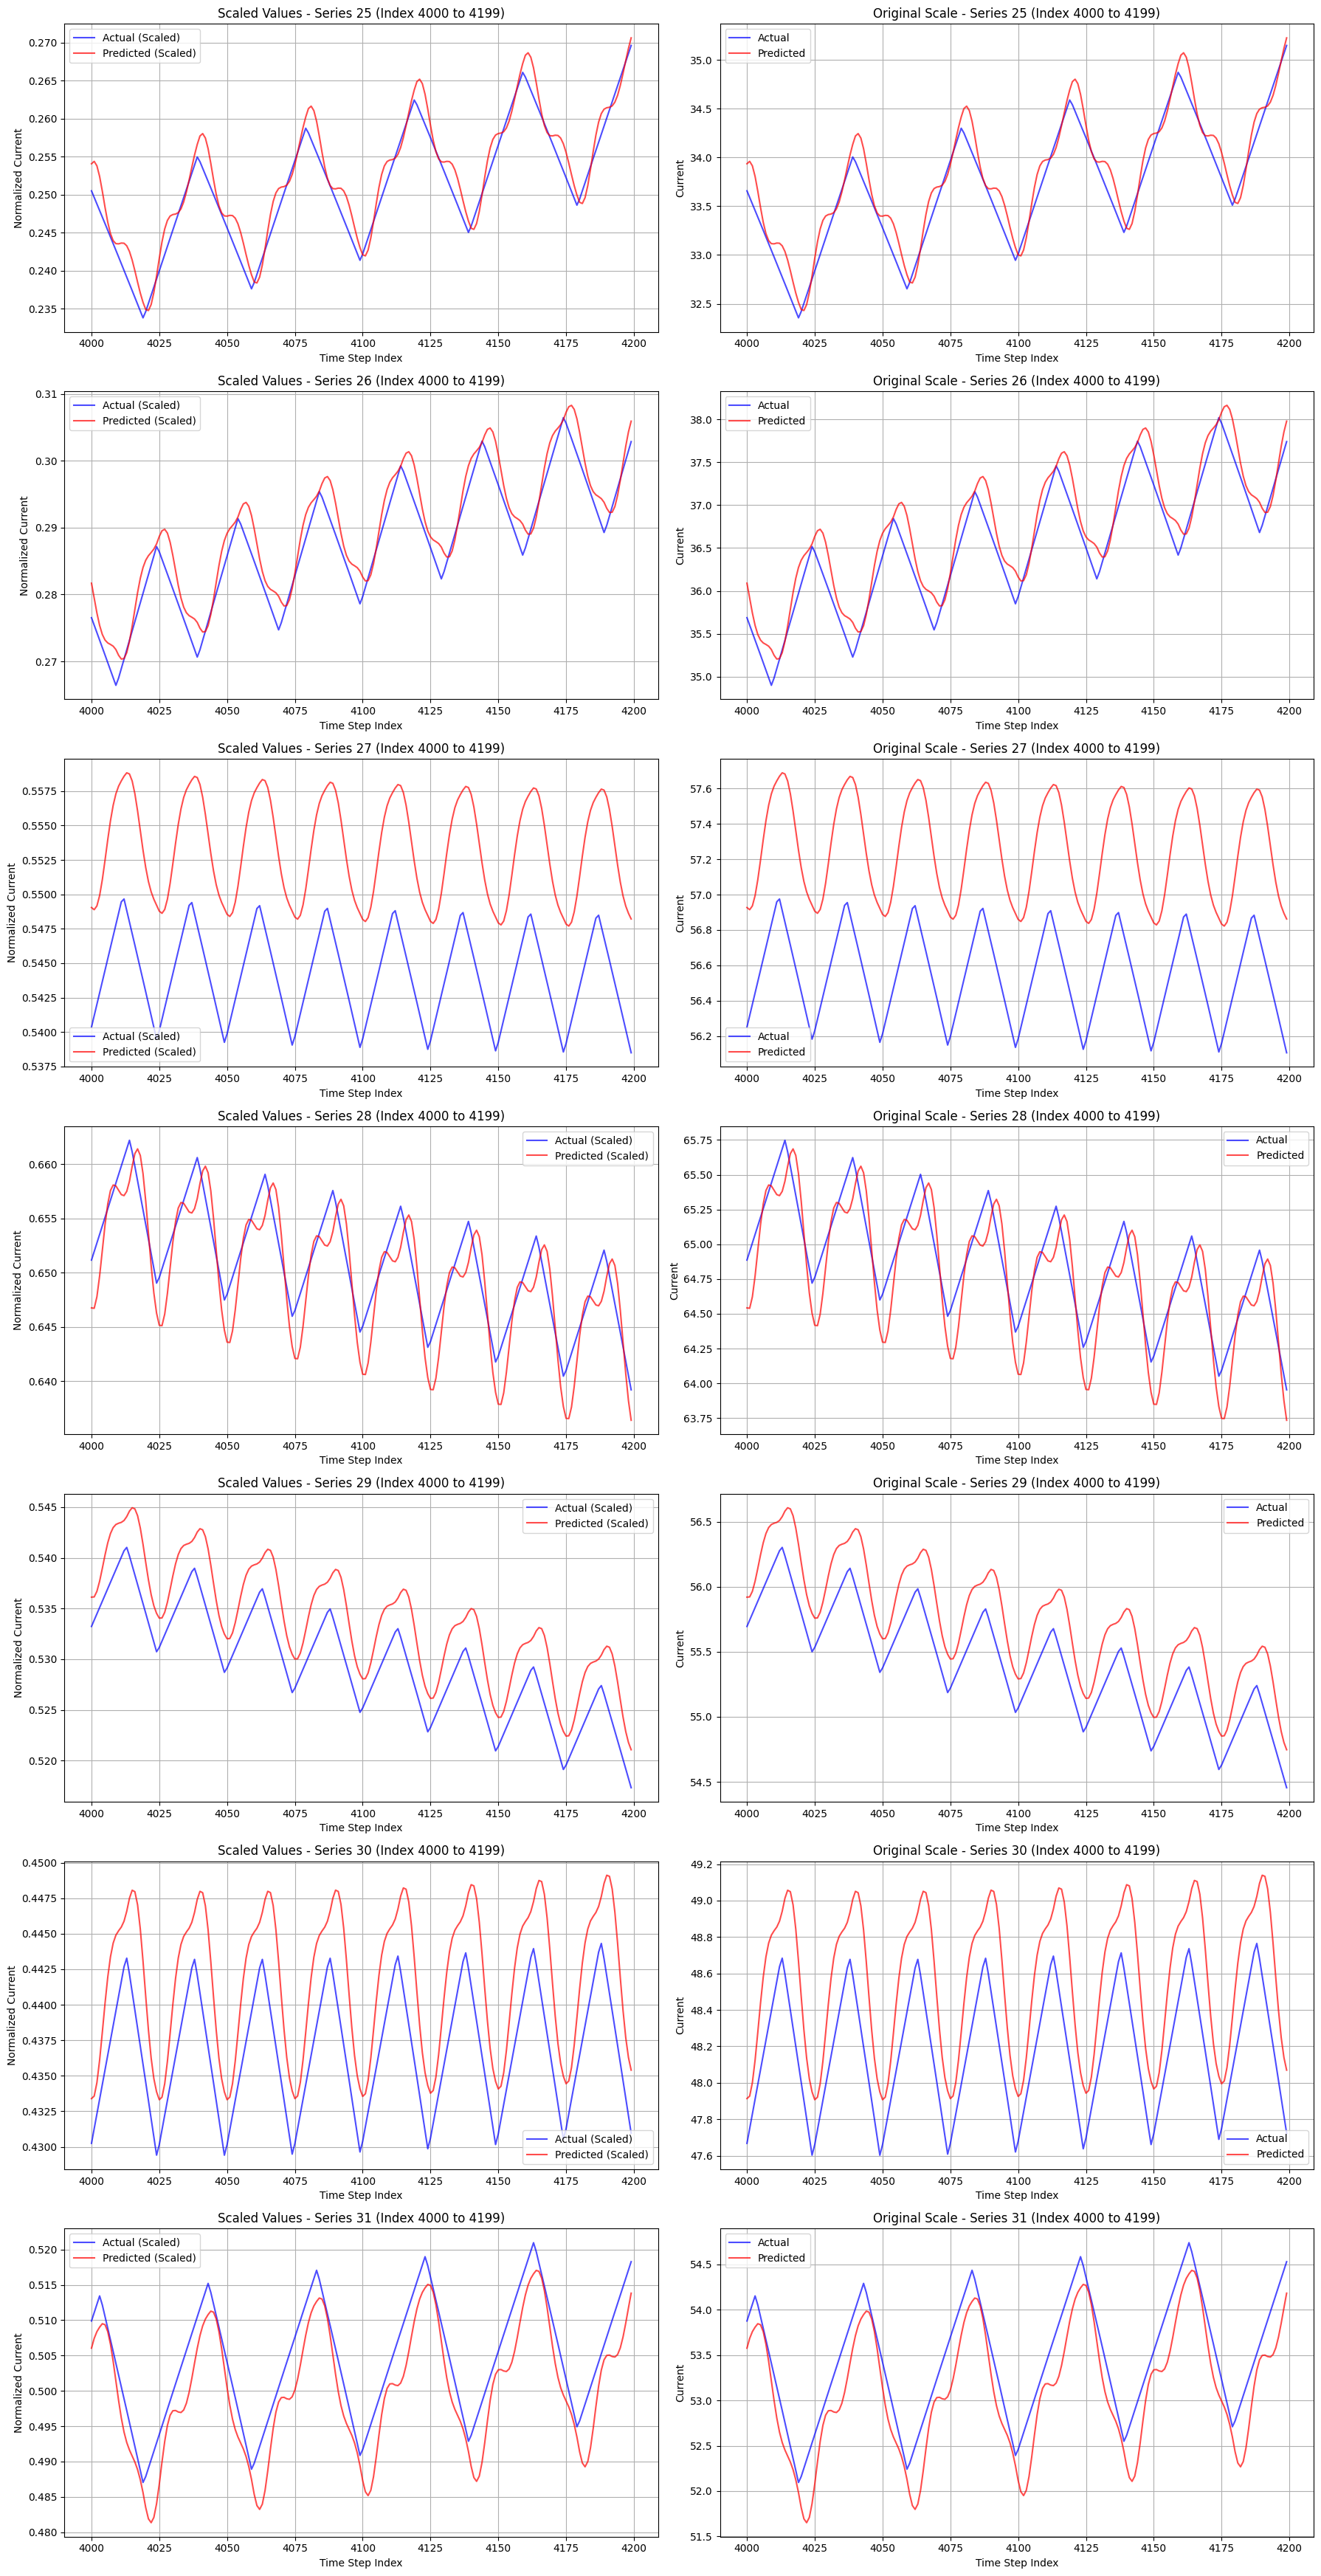

In [11]:
# Function to create zoomed-in plots for all test series starting from the 4000th value
def plot_zoomed_series(X_test_scaled, test_series_ids, y_test_scaled, y_pred_scaled, scaler_y, start_idx=4000, window_size=200):
    """
    Create zoomed-in plots for all test series showing a window of specified size starting from a specific index

    Parameters:
    -----------
    X_test_scaled: array-like, scaled test features
    test_series_ids: array-like, identifiers for each series in the test set
    y_test_scaled: array-like, scaled actual values
    y_pred_scaled: array-like, scaled predicted values
    scaler_y: scaler object to inverse transform the scaled values
    start_idx: int, starting index for visualization (default=4000)
    window_size: int, number of time steps to visualize (default=200)
    """
    # Get unique test series IDs
    unique_test_series = np.unique(test_series_ids)
    num_series = len(unique_test_series)

    # Create a figure with subplots
    fig, axes = plt.subplots(num_series, 2, figsize=(18, 5*num_series))

    # If there's only one series, wrap axes in a list to make code consistent
    if num_series == 1:
        axes = np.array([axes])

    # Loop through each test series
    for i, series_id in enumerate(unique_test_series):
        # Get mask for current series
        series_mask = (test_series_ids == series_id)

        # Get scaled values
        scaled_actual = y_test_scaled[series_mask]
        scaled_pred = y_pred_scaled[series_mask]

        # Check if series is long enough for requested start index
        if len(scaled_actual) <= start_idx:
            print(f"Warning: Series {series_id} has only {len(scaled_actual)} points, which is less than the requested start index {start_idx}.")
            print(f"Showing the last {min(window_size, len(scaled_actual))} points instead.")
            # If not enough data, show the last window_size points or all available data
            start = max(0, len(scaled_actual) - window_size)
            end = len(scaled_actual)
        else:
            # Ensure we don't exceed the available data
            start = start_idx
            end = min(start_idx + window_size, len(scaled_actual))

        # Get the window of values
        scaled_actual_window = scaled_actual[start:end]
        scaled_pred_window = scaled_pred[start:end]

        # Create x-axis values for plotting (showing the actual indices)
        x_values = np.arange(start, end)

        # Inverse transform to get original scale values
        original_actual_window = scaler_y.inverse_transform(scaled_actual_window.reshape(-1, 1)).flatten()
        original_pred_window = scaler_y.inverse_transform(scaled_pred_window.reshape(-1, 1)).flatten()

        # Plot scaled values
        axes[i, 0].plot(x_values, scaled_actual_window, label='Actual (Scaled)', color='blue', alpha=0.7)
        axes[i, 0].plot(x_values, scaled_pred_window, label='Predicted (Scaled)', color='red', alpha=0.7)
        axes[i, 0].set_title(f'Scaled Values - Series {series_id} (Index {start} to {end-1})')
        axes[i, 0].set_xlabel('Time Step Index')
        axes[i, 0].set_ylabel('Normalized Current')
        axes[i, 0].grid(True)
        axes[i, 0].legend()

        # Plot original values
        axes[i, 1].plot(x_values, original_actual_window, label='Actual', color='blue', alpha=0.7)
        axes[i, 1].plot(x_values, original_pred_window, label='Predicted', color='red', alpha=0.7)
        axes[i, 1].set_title(f'Original Scale - Series {series_id} (Index {start} to {end-1})')
        axes[i, 1].set_xlabel('Time Step Index')
        axes[i, 1].set_ylabel('Current')
        axes[i, 1].grid(True)
        axes[i, 1].legend()

        # Print statistics for this window
        print(f"\nSeries {series_id} Statistics (Index {start} to {end-1}):")
        print("Scaled Values Range:")
        print(f"Actual: [{scaled_actual_window.min():.3f}, {scaled_actual_window.max():.3f}]")
        print(f"Predicted: [{scaled_pred_window.min():.3f}, {scaled_pred_window.max():.3f}]")
        print("Original Values Range:")
        print(f"Actual: [{original_actual_window.min():.3f}, {original_actual_window.max():.3f}]")
        print(f"Predicted: [{original_pred_window.min():.3f}, {original_pred_window.max():.3f}]")

    plt.tight_layout()
    plt.show()

# Call the function to plot zoomed views of all test series
plot_zoomed_series(
    X_test_scaled,
    series_ids_test,
    y_test_scaled,
    y_pred_scaled,
    scaler_y,
    start_idx=4000,  # Start from the 4000th value
    window_size=200  # Show 200 values
)

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Embedding, Concatenate, Dropout, Reshape
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow as tf

def build_pooled_brann_model(n_steps, n_features, n_series):
    """
    Build a pooled Bayesian Ridge ANN model with series identifiers
    """
    # Input layers
    time_series_input = Input(shape=(n_steps, n_features), name='time_series_input')
    series_id_input = Input(shape=(1,), name='series_id_input')

    # Embed the series identifier
    embedding_dim = min(5, (n_series + 1) // 2)  # Rule of thumb for embedding dimension
    series_embedding = Embedding(input_dim=n_series, output_dim=embedding_dim)(series_id_input)
    series_embedding = Dense(embedding_dim)(series_embedding)
    series_embedding = Dropout(0.2)(series_embedding)

    # Instead of LSTM, use Dense layers for BR-ANN
    # First flatten the time series input
    flattened_input = Reshape((n_steps * n_features,))(time_series_input)

    # Process flattened time series with dense layers
    dense1 = Dense(128, activation='relu')(flattened_input)
    dense1 = Dropout(0.2)(dense1)
    dense2 = Dense(64, activation='relu')(dense1)
    dense2 = Dropout(0.2)(dense2)

    # Flatten embedding before concatenation
    series_embedding_flat = Dense(embedding_dim, activation='relu')(series_embedding[:, 0, :])

    # Combine features
    concatenated = Concatenate()([dense2, series_embedding_flat])

    # Bayesian layers - use Dense with custom regularization for approximate Bayesian behavior
    bayesian_dense = Dense(32, activation='relu',
                          kernel_regularizer='l2',
                          bias_regularizer='l2')(concatenated)
    bayesian_dense = Dropout(0.3)(bayesian_dense)  # Dropout for uncertainty approximation

    # Output layer
    output = Dense(1)(bayesian_dense)

    # Define model
    model = Model(inputs=[time_series_input, series_id_input], outputs=output)

    # Use Adam optimizer with a smaller learning rate for better convergence
    from tensorflow.keras.optimizers import Adam
    optimizer = Adam(learning_rate=0.001)

    # Compile model
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    return model

# Main execution code
# Assuming these variables are already defined from your LSTM model:
# X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled,
# series_ids_train, series_ids_test, series_ids, test_series

# Get dimensions for model
n_steps = X_train_scaled.shape[1]  # Number of time steps from your data
n_features = X_train_scaled.shape[2]  # Number of features from your data
n_series = len(np.unique(series_ids))  # Number of unique series IDs

# Build the BR-ANN model
brann_model = build_pooled_brann_model(n_steps, n_features, n_series)

# Display model summary
brann_model.summary()

# Reshape series IDs for model input
train_series_ids = series_ids_train.reshape(-1, 1)
test_series_ids = series_ids_test.reshape(-1, 1)

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    'best_brann_model.h5',
    monitor='val_loss',
    save_best_only=True
)

# Train the BR-ANN model
brann_history = brann_model.fit(
    [X_train_scaled, train_series_ids],  # Same input data used in LSTM
    y_train_scaled,                       # Same target data used in LSTM
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Get predictions from BR-ANN model

print(f"Overall BR-ANN MSE: {brann_overall_mse:.4f}, MAE: {brann_overall_mae:.4f}")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ time_series_input   │ (None, 100, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ series_id_input     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 100)       │          0 │ time_series_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 5)      │        160 │ series_id_input[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     12,928 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1, 5)      │         30 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1, 5)      │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      8,256 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 5)         │          0 │ dropout_2[0][0]   │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 5)         │         30 │ get_item_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 69)        │          0 │ dropout_4[0][0],  │
│ (Concatenate)       │                   │            │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 32)        │      2,240 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 32)        │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │         33 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,677 (92.49 KB)

 Trainable params: 23,677 (92.49 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
6182/6188 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0700 - mae: 0.0997

6188/6188 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - loss: 0.0700 - mae: 0.0996 - val_loss: 0.0033 - val_mae: 0.0378
Epoch 2/50
6188/6188 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 0.0048 - mae: 0.0488 - val_loss: 0.0070 - val_mae: 0.0727
Epoch 3/50
6188/6188 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 0.0044 - mae: 0.0461 - val_loss: 0.0122 - val_mae: 0.0973
Epoch 4/50
6188/6188 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 0.0043 - mae: 0.0456 - val_loss: 0.0061 - val_mae: 0.0666
Epoch 5/50
6188/6188 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 0.0042 - mae: 0.0445 - val_loss: 0.0159 - val_mae: 0.1128
Epoch 6/50
6188/6188 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 0.0040 - mae: 0.0435 - val_loss: 0.0131 - val_mae: 0.1011
Epoch 7/50
6188/6188 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - loss: 0.0039 - mae: 0.0432 - val_loss: 0.0165 - val_mae: 0.1121
Epoch 8/50
6188/6188 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 0.0038 - mae: 0.0424 - val_loss: 0.0096 - val_mae: 0.0839
Epoch 9/50
6188/6188 ━━━━━━━━━━━━━━━━━━━━ 2

NameError: name 'brann_overall_mse' is not defined

In [13]:
brann_pred_scaled = brann_model.predict([X_test_scaled, test_series_ids])



2166/2166 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step



Evaluation Metrics by Series:
   Series_ID       MAE        MSE      RMSE  MAE_Scaled  MSE_Scaled
0         25  5.596009  37.520561  6.125403    0.071798    0.006176
1         26  5.303578  36.420400  6.034932    0.068046    0.005995
2         27  0.741566   4.158225  2.039173    0.009514    0.000685
3         28  1.302027   4.328853  2.080590    0.016705    0.000713
4         29  1.024693   5.800091  2.408338    0.013147    0.000955
5         30  1.088496   3.794999  1.948076    0.013966    0.000625
6         31  0.874173   2.453852  1.566478    0.011216    0.000404


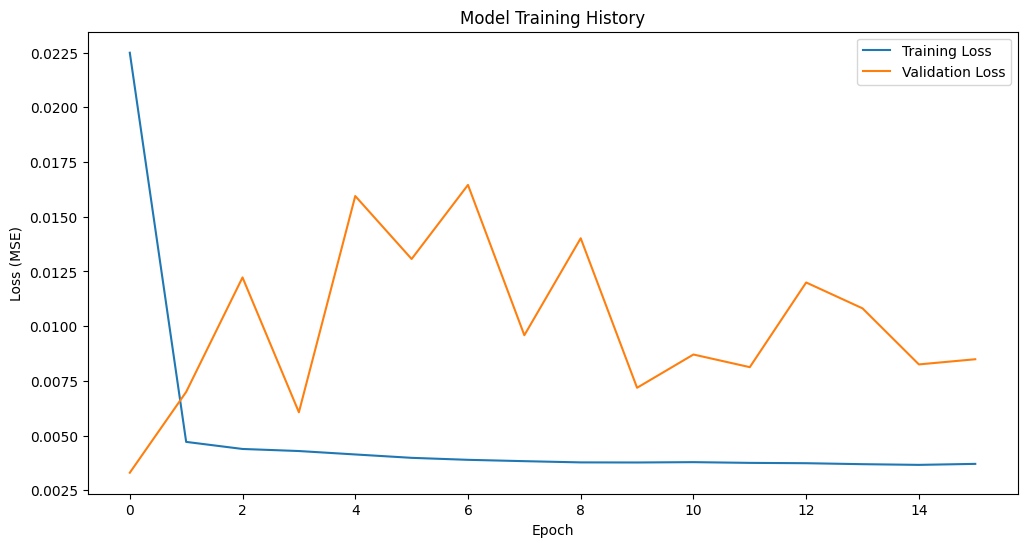

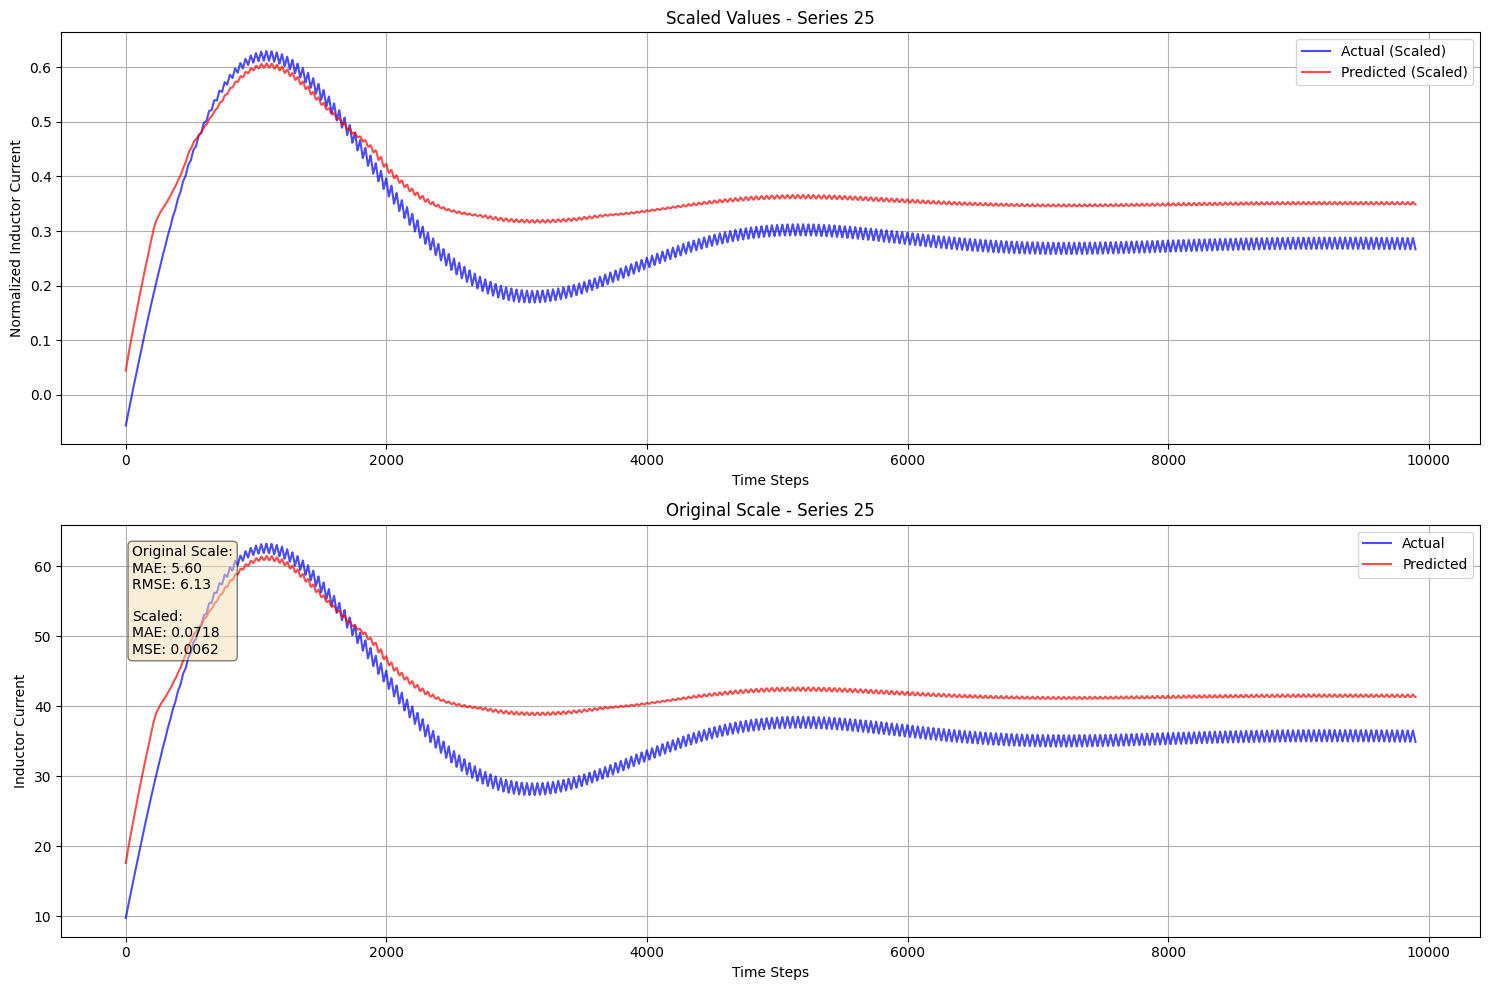

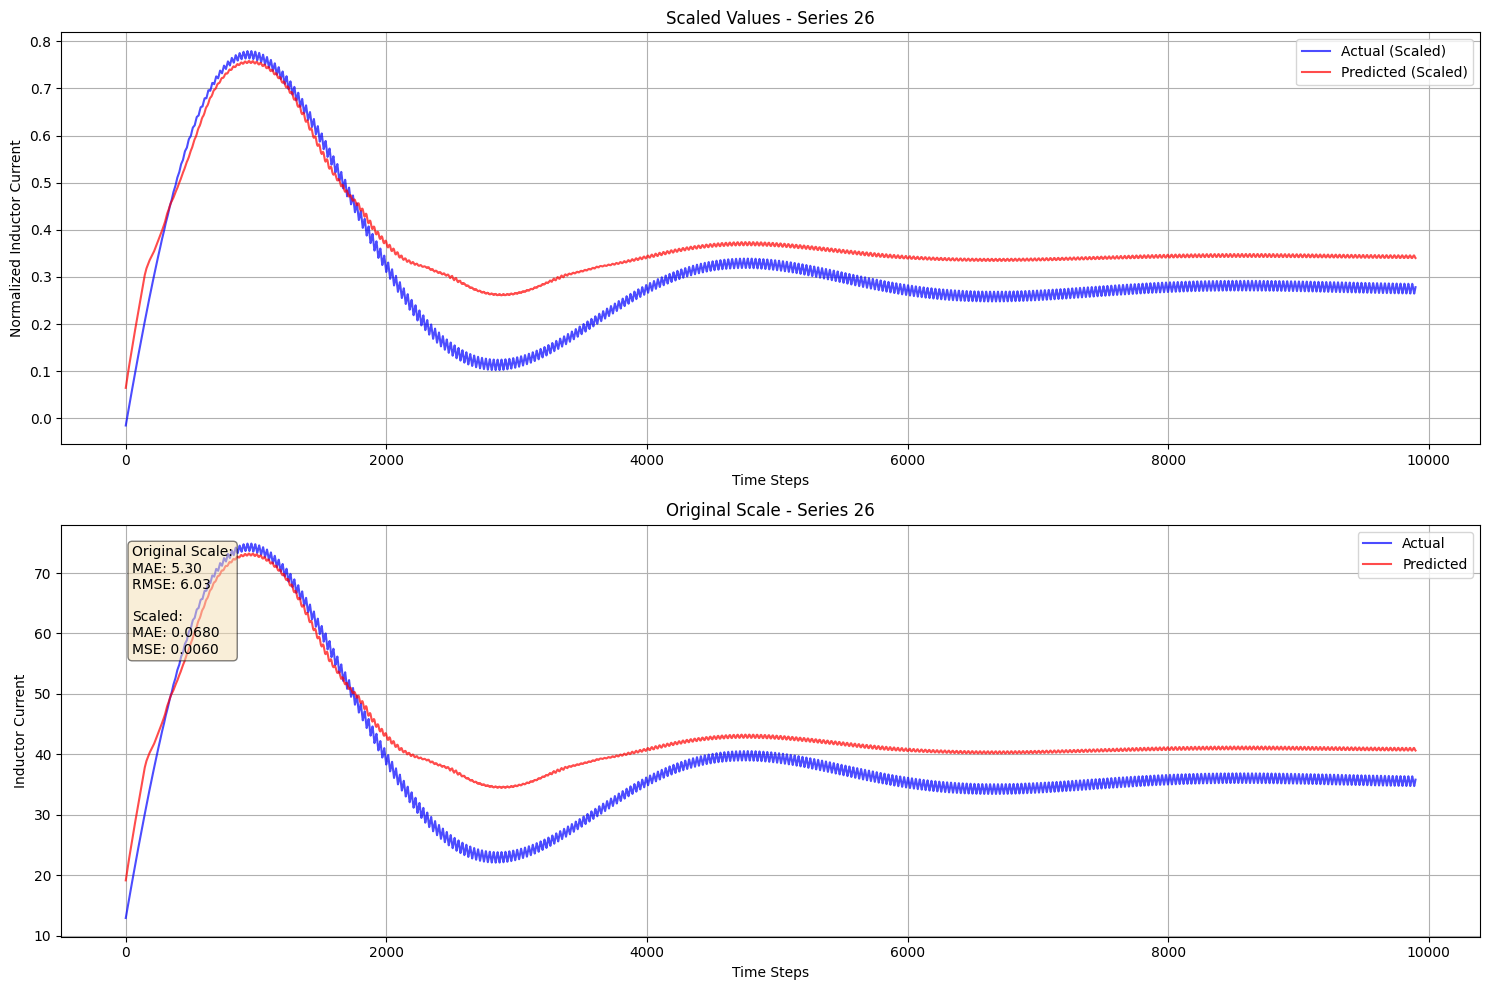

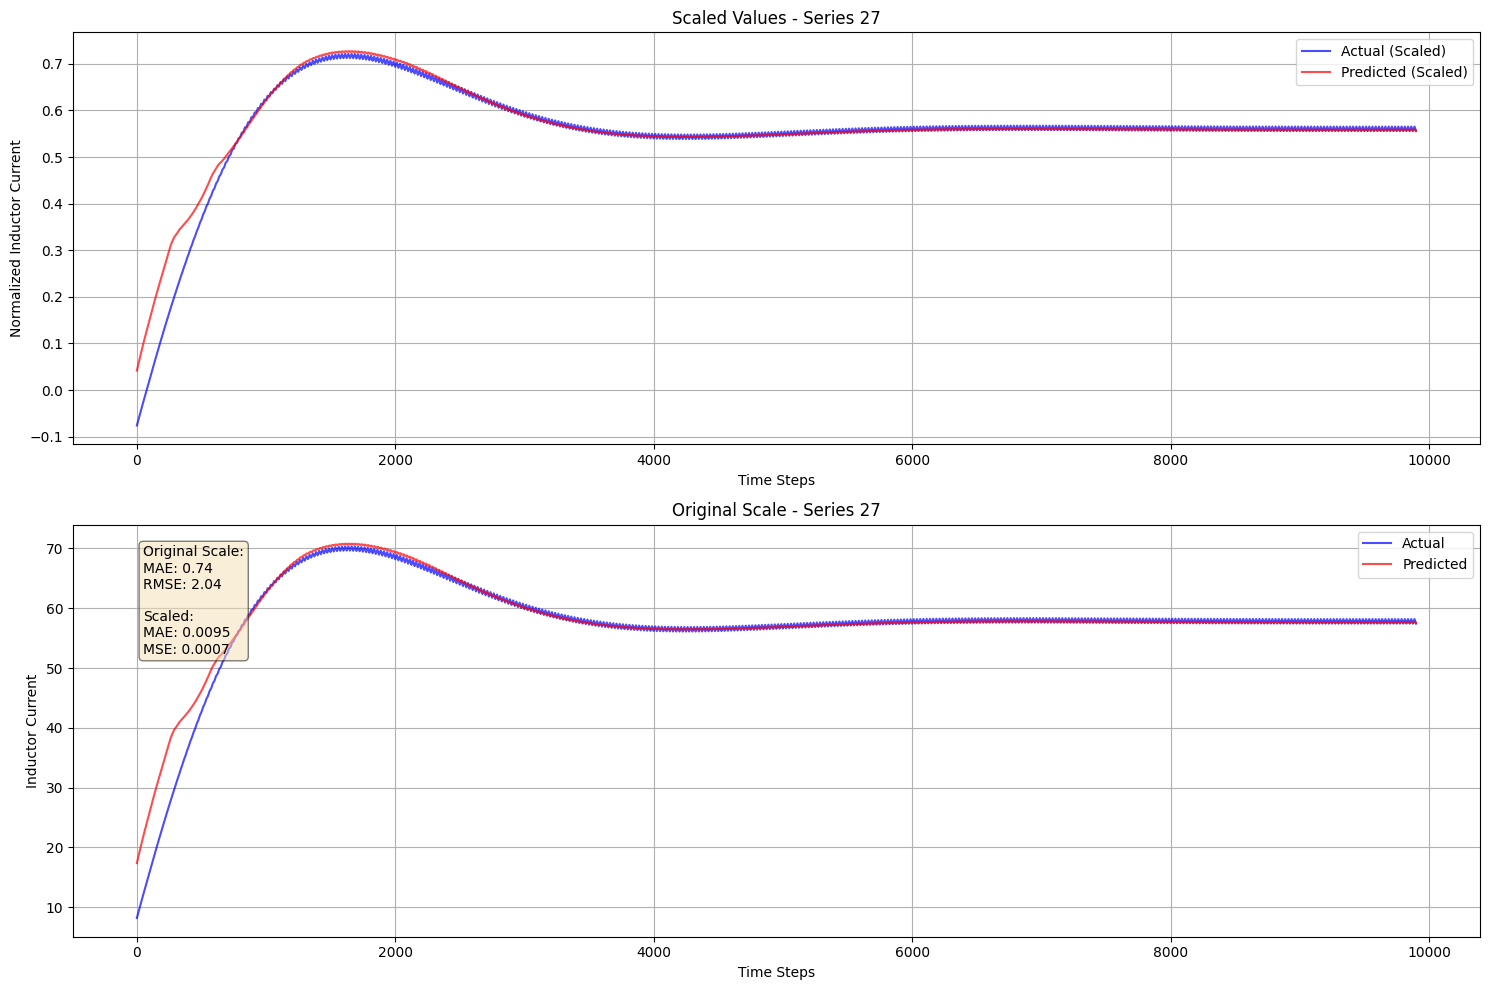

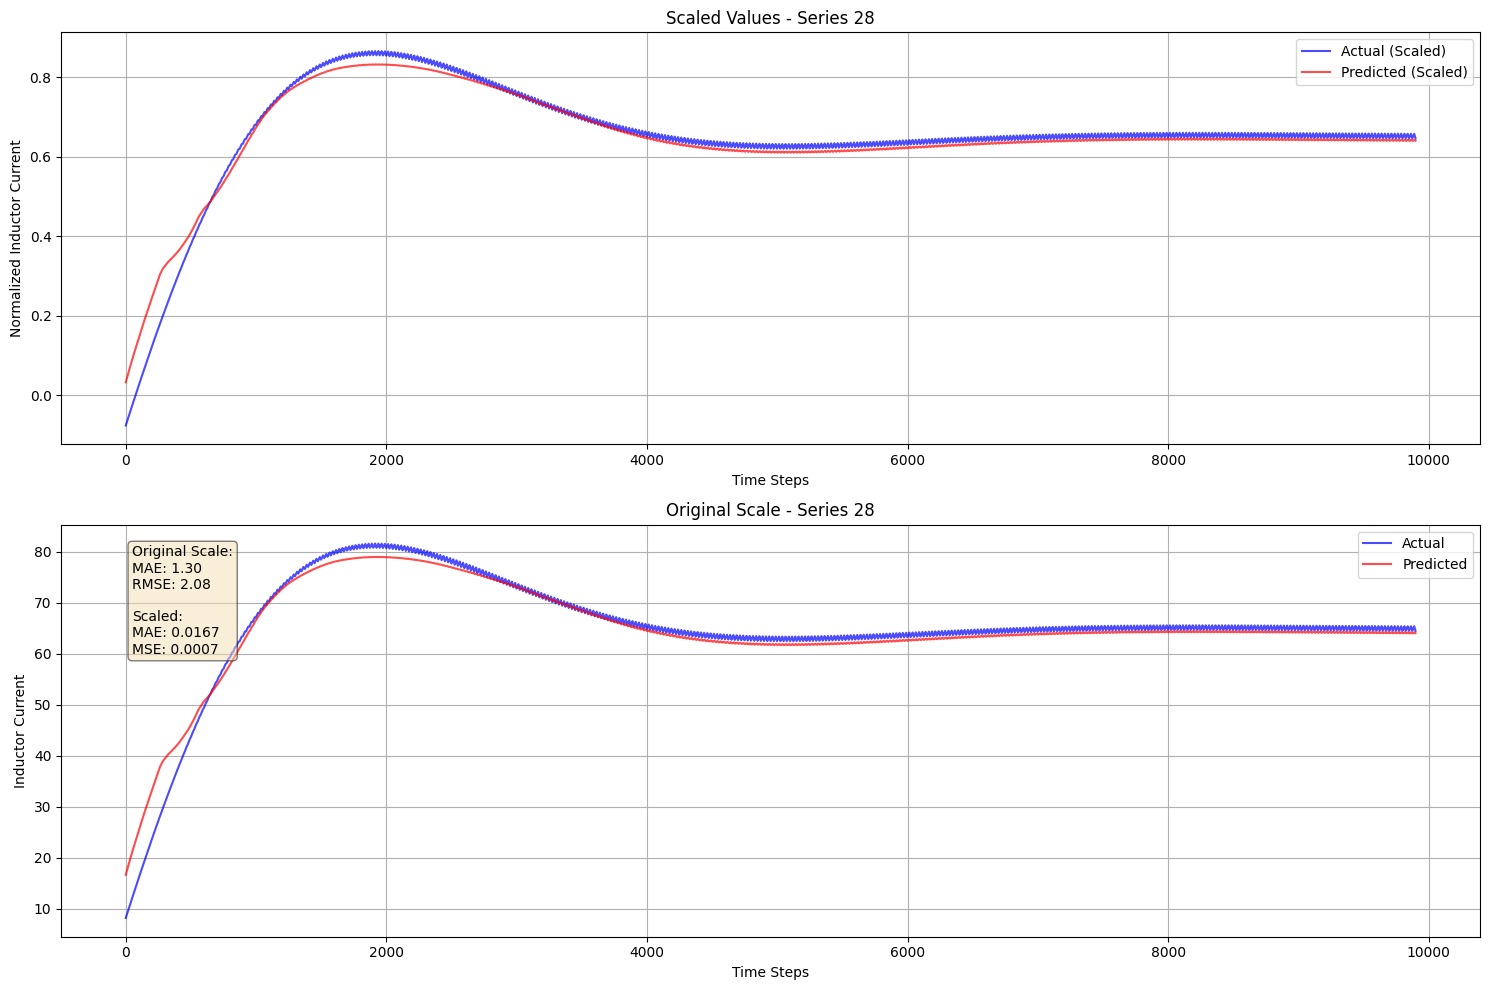

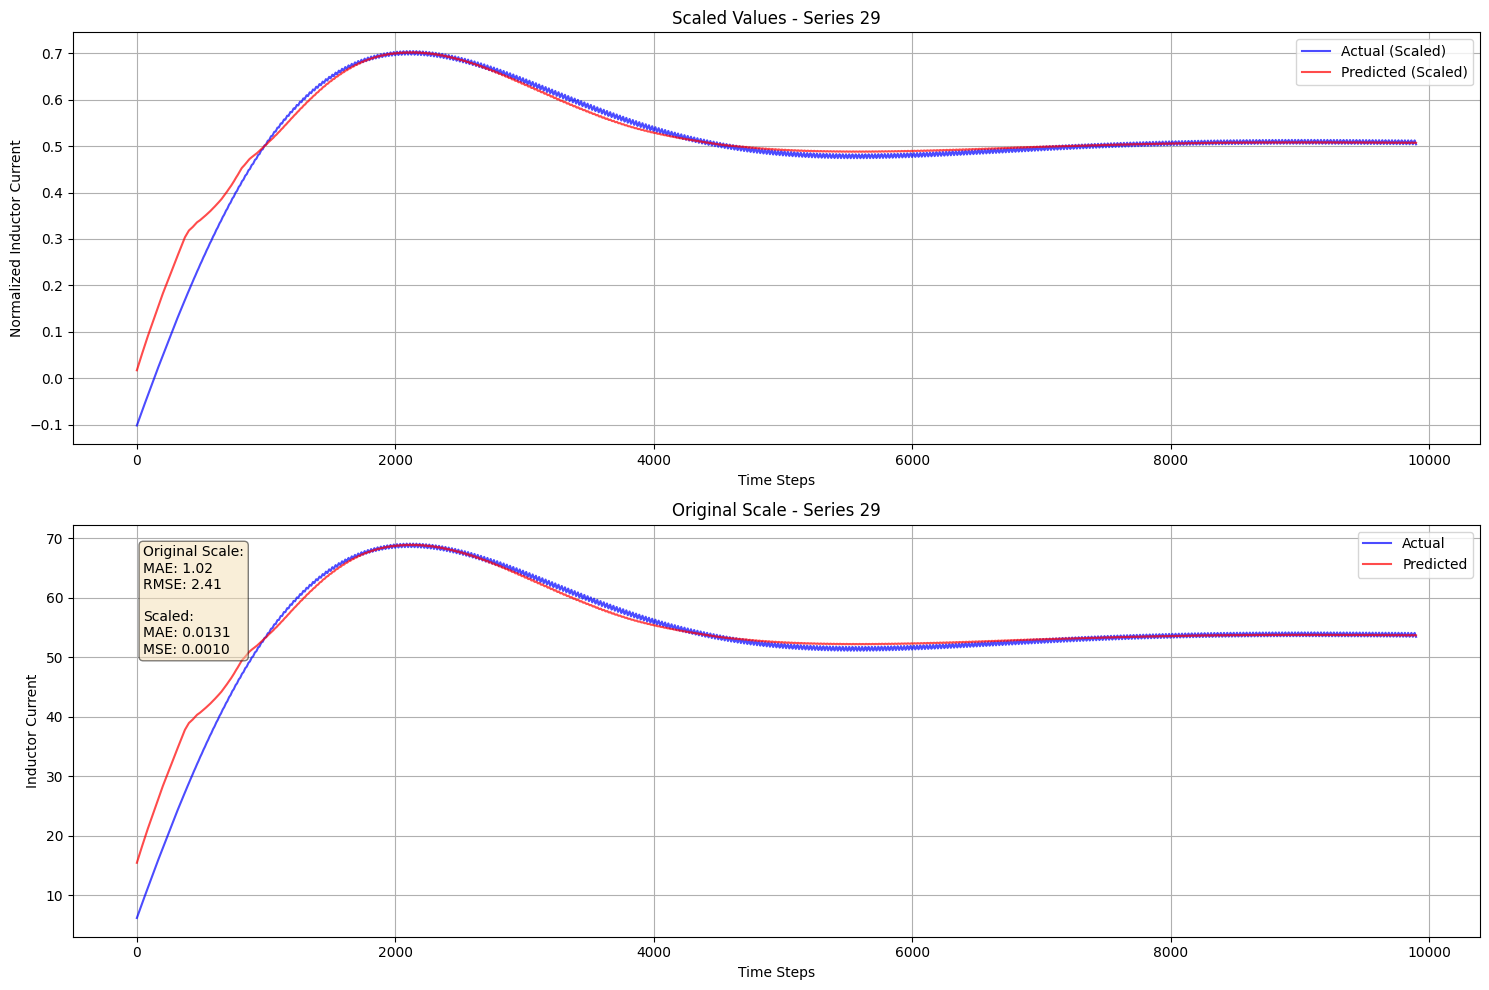

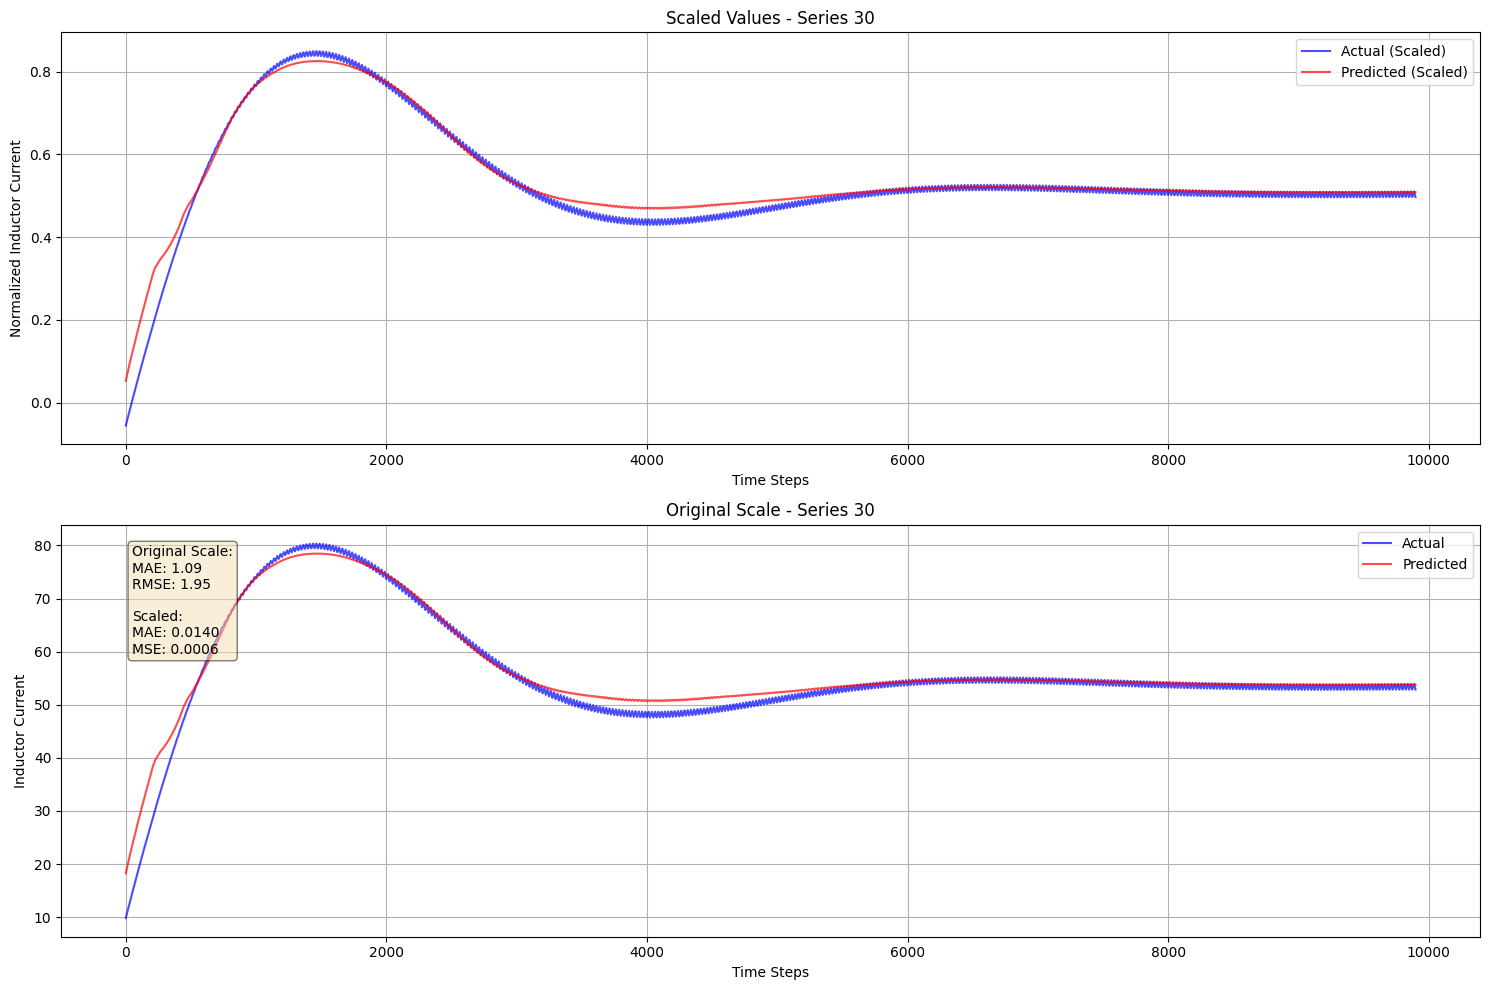

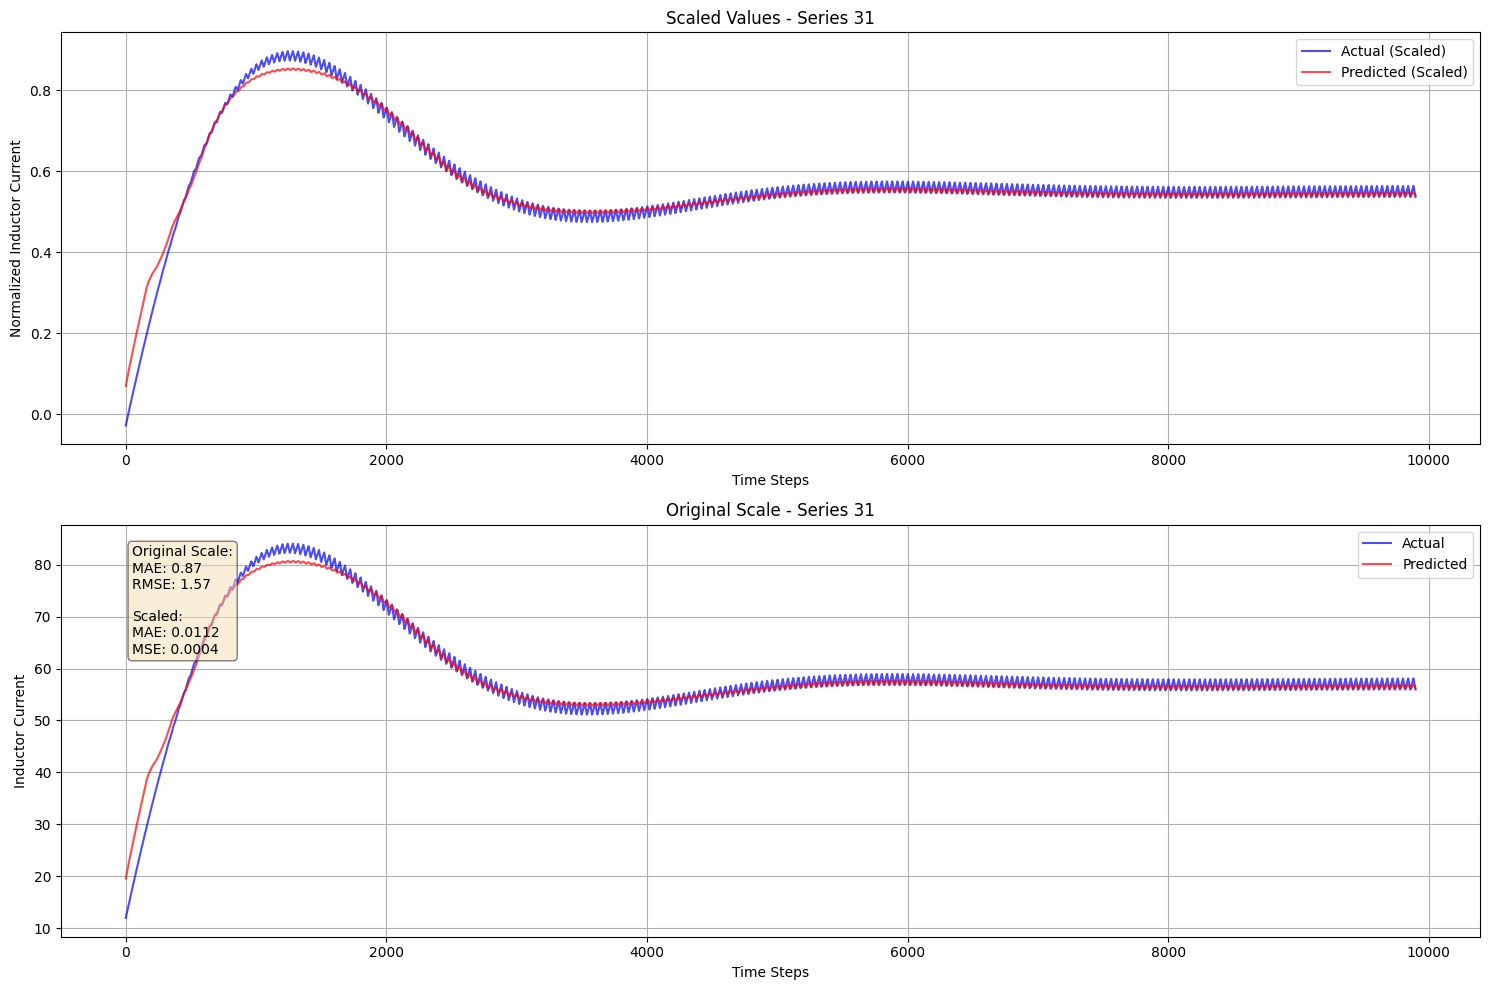


Scaled Values Range Across All Series:
Actual: [-0.102, 0.897]
Predicted: [0.017, 0.854]

Original Values Range Across All Series:
Actual: [6.178, 84.068]
Predicted: [15.453, 80.723]

Overall Evaluation Metrics:
Original Scale:
MAE: 2.2758
MSE: 13.4967
RMSE: 3.6738

Scaled:
MAE: 0.0292
MSE: 0.0022


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Inverse transform the scaled predictions and actual values
brann_pred = scaler_y.inverse_transform(brann_pred_scaled)
y_test = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1))

# 2. Create a DataFrame with the results and series IDs
results_df = pd.DataFrame({
    'Series_ID': series_ids_test.flatten(),
    'Actual': y_test.flatten(),
    'Predicted': brann_pred.flatten(),
    'Actual_Scaled': y_test_scaled.flatten(),
    'Predicted_Scaled': brann_pred_scaled.flatten()
})

# 3. Calculate metrics for each series (both scaled and original)
series_metrics = []
unique_series = results_df['Series_ID'].unique()

for series_id in unique_series:
    series_data = results_df[results_df['Series_ID'] == series_id]

    # Original scale metrics
    actual = series_data['Actual']
    predicted = series_data['Predicted']
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)

    # Scaled metrics
    actual_scaled = series_data['Actual_Scaled']
    predicted_scaled = series_data['Predicted_Scaled']
    mae_scaled = mean_absolute_error(actual_scaled, predicted_scaled)
    mse_scaled = mean_squared_error(actual_scaled, predicted_scaled)

    series_metrics.append({
        'Series_ID': series_id,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAE_Scaled': mae_scaled,
        'MSE_Scaled': mse_scaled
    })

# Convert metrics to DataFrame
metrics_df = pd.DataFrame(series_metrics)
print("\nEvaluation Metrics by Series:")
print(metrics_df)

# 4. Plot training history
plt.figure(figsize=(12, 6))
plt.plot(brann_history.history['loss'], label='Training Loss')
plt.plot(brann_history.history['val_loss'], label='Validation Loss')
plt.title('Model Training History')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# 5. Plot actual vs predicted for each series (both scaled and original)
for series_id in unique_series:
    series_data = results_df[results_df['Series_ID'] == series_id]

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

    # Plot scaled values
    ax1.plot(series_data['Actual_Scaled'].values, label='Actual (Scaled)', color='blue', alpha=0.7)
    ax1.plot(series_data['Predicted_Scaled'].values, label='Predicted (Scaled)', color='red', alpha=0.7)
    ax1.set_title(f'Scaled Values - Series {series_id}')
    ax1.set_xlabel('Time Steps')
    ax1.set_ylabel('Normalized Inductor Current')
    ax1.grid(True)
    ax1.legend()

    # Plot original values
    ax2.plot(series_data['Actual'].values, label='Actual', color='blue', alpha=0.7)
    ax2.plot(series_data['Predicted'].values, label='Predicted', color='red', alpha=0.7)
    ax2.set_title(f'Original Scale - Series {series_id}')
    ax2.set_xlabel('Time Steps')
    ax2.set_ylabel('Inductor Current')
    ax2.grid(True)
    ax2.legend()

    # Get metrics for this series
    metrics = metrics_df[metrics_df['Series_ID'] == series_id].iloc[0]

    # Add metrics text box
    textstr = '\n'.join((
        f'Original Scale:',
        f'MAE: {metrics["MAE"]:.2f}',
        f'RMSE: {metrics["RMSE"]:.2f}',
        f'\nScaled:',
        f'MAE: {metrics["MAE_Scaled"]:.4f}',
        f'MSE: {metrics["MSE_Scaled"]:.4f}'
    ))
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax2.text(0.05, 0.95, textstr, transform=ax2.transAxes,
            fontsize=10, verticalalignment='top', bbox=props)

    plt.tight_layout()
    plt.show()

# 6. Print value ranges for all series
print("\nScaled Values Range Across All Series:")
print(f"Actual: [{results_df['Actual_Scaled'].min():.3f}, {results_df['Actual_Scaled'].max():.3f}]")
print(f"Predicted: [{results_df['Predicted_Scaled'].min():.3f}, {results_df['Predicted_Scaled'].max():.3f}]")
print("\nOriginal Values Range Across All Series:")
print(f"Actual: [{results_df['Actual'].min():.3f}, {results_df['Actual'].max():.3f}]")
print(f"Predicted: [{results_df['Predicted'].min():.3f}, {results_df['Predicted'].max():.3f}]")

# 7. Calculate and print overall metrics
overall_mae = mean_absolute_error(results_df['Actual'], results_df['Predicted'])
overall_mse = mean_squared_error(results_df['Actual'], results_df['Predicted'])
overall_rmse = np.sqrt(overall_mse)
overall_mae_scaled = mean_absolute_error(results_df['Actual_Scaled'], results_df['Predicted_Scaled'])
overall_mse_scaled = mean_squared_error(results_df['Actual_Scaled'], results_df['Predicted_Scaled'])

print("\nOverall Evaluation Metrics:")
print("Original Scale:")
print(f"MAE: {overall_mae:.4f}")
print(f"MSE: {overall_mse:.4f}")
print(f"RMSE: {overall_rmse:.4f}")
print("\nScaled:")
print(f"MAE: {overall_mae_scaled:.4f}")
print(f"MSE: {overall_mse_scaled:.4f}")

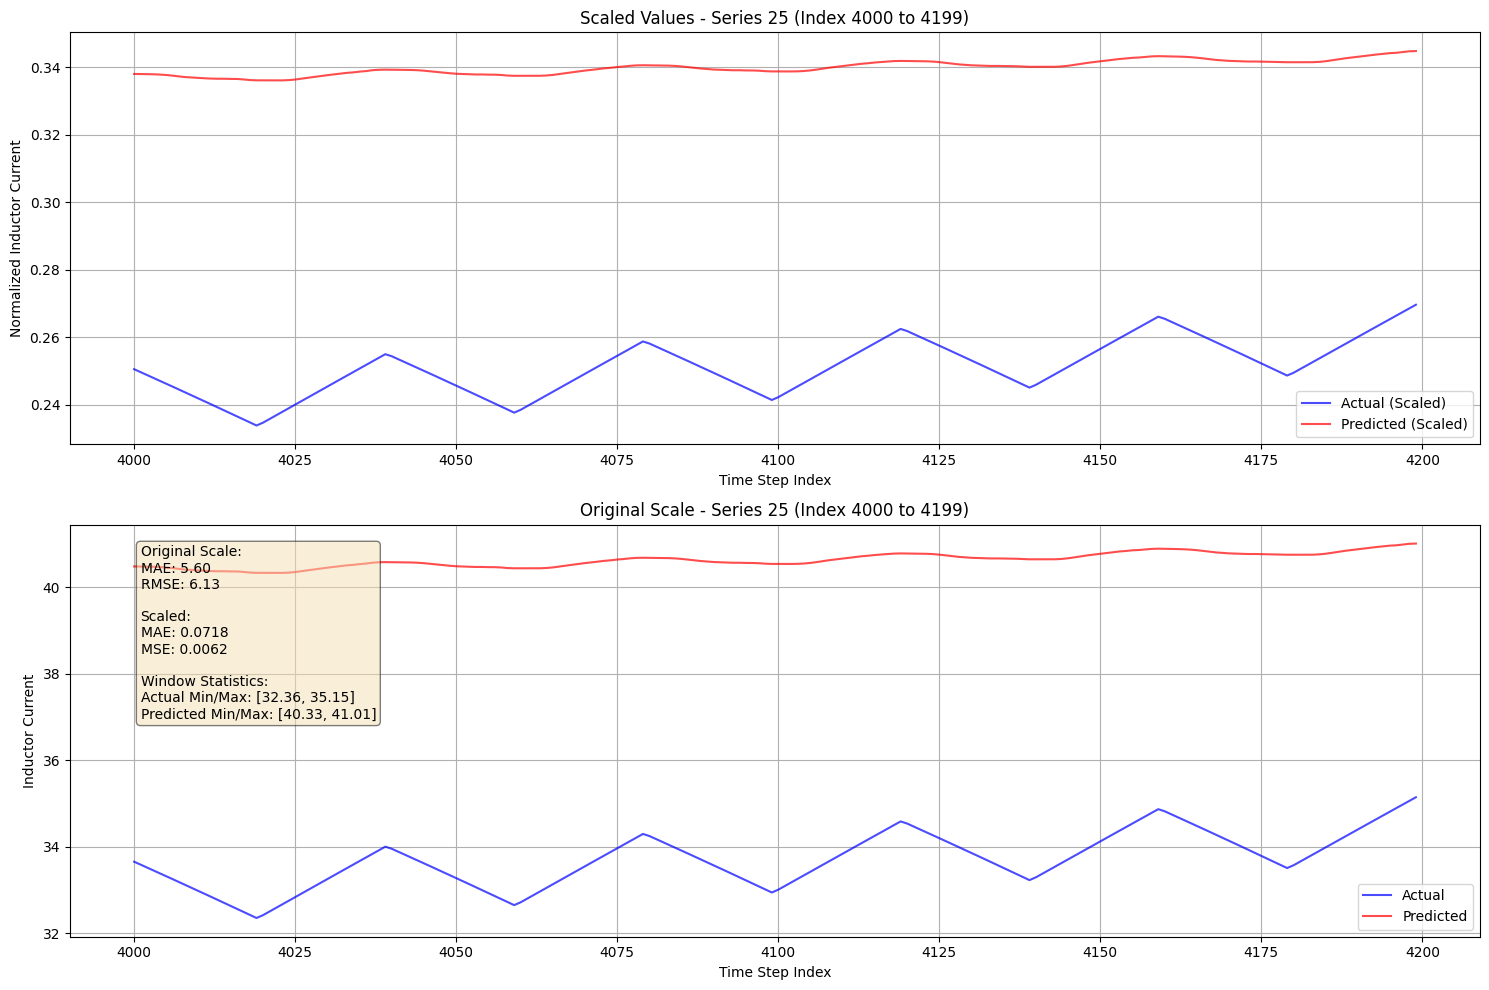


Series 25 Window Statistics (Index 4000 to 4199):
Scaled Values Range:
Actual: [0.234, 0.270]
Predicted: [0.336, 0.345]
Original Values Range:
Actual: [32.356, 35.148]
Predicted: [40.333, 41.013]


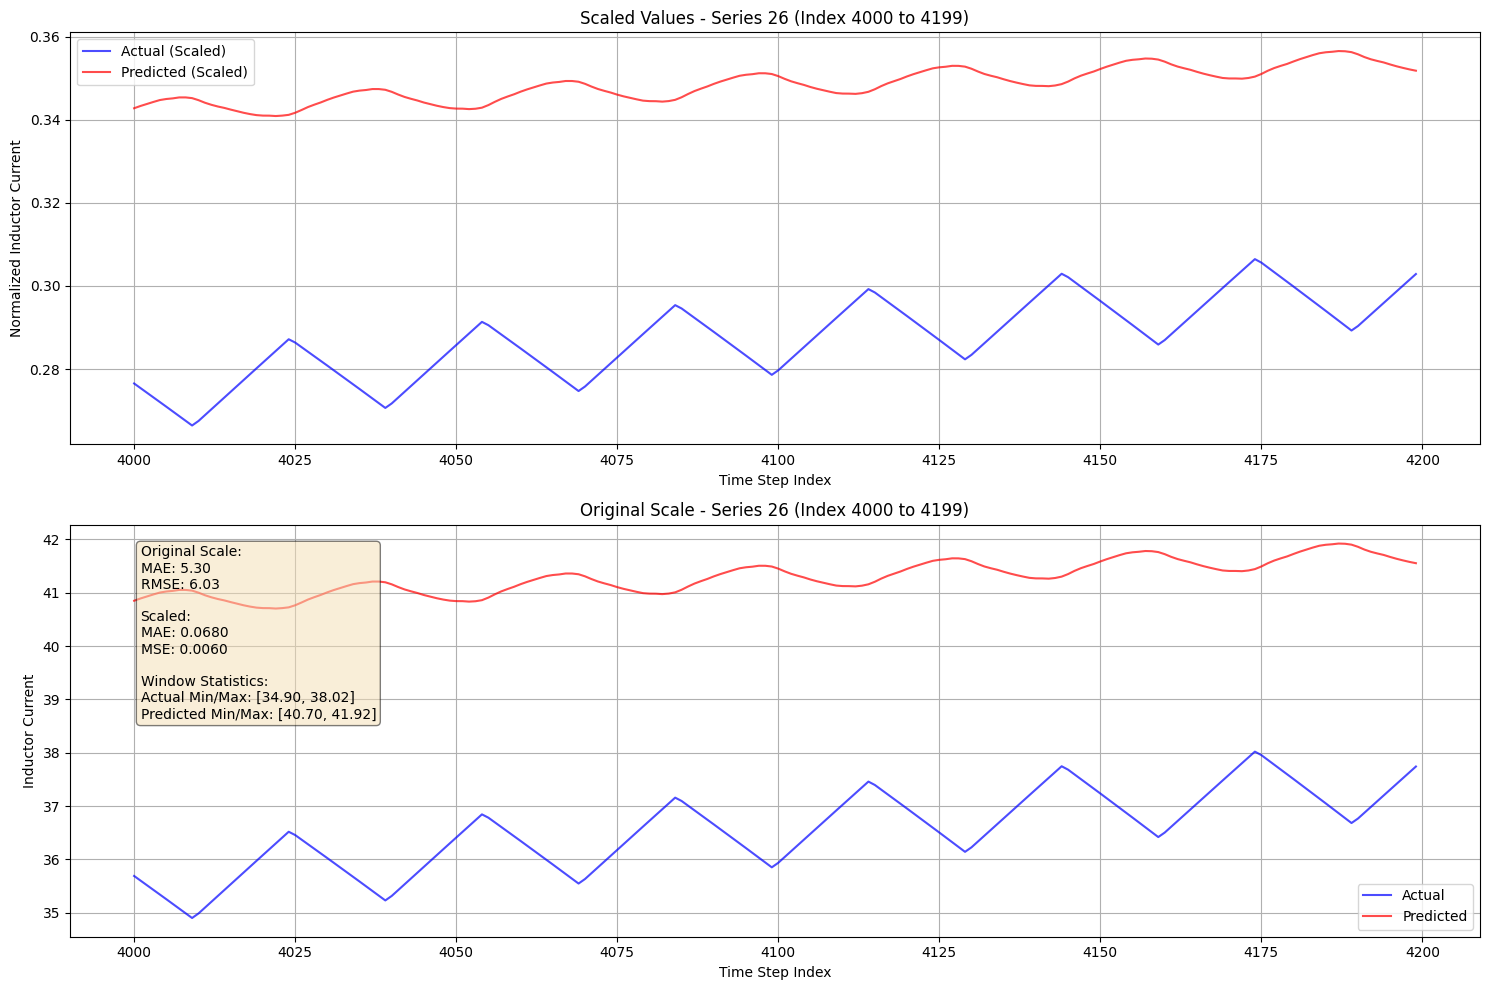


Series 26 Window Statistics (Index 4000 to 4199):
Scaled Values Range:
Actual: [0.266, 0.306]
Predicted: [0.341, 0.357]
Original Values Range:
Actual: [34.899, 38.020]
Predicted: [40.704, 41.923]


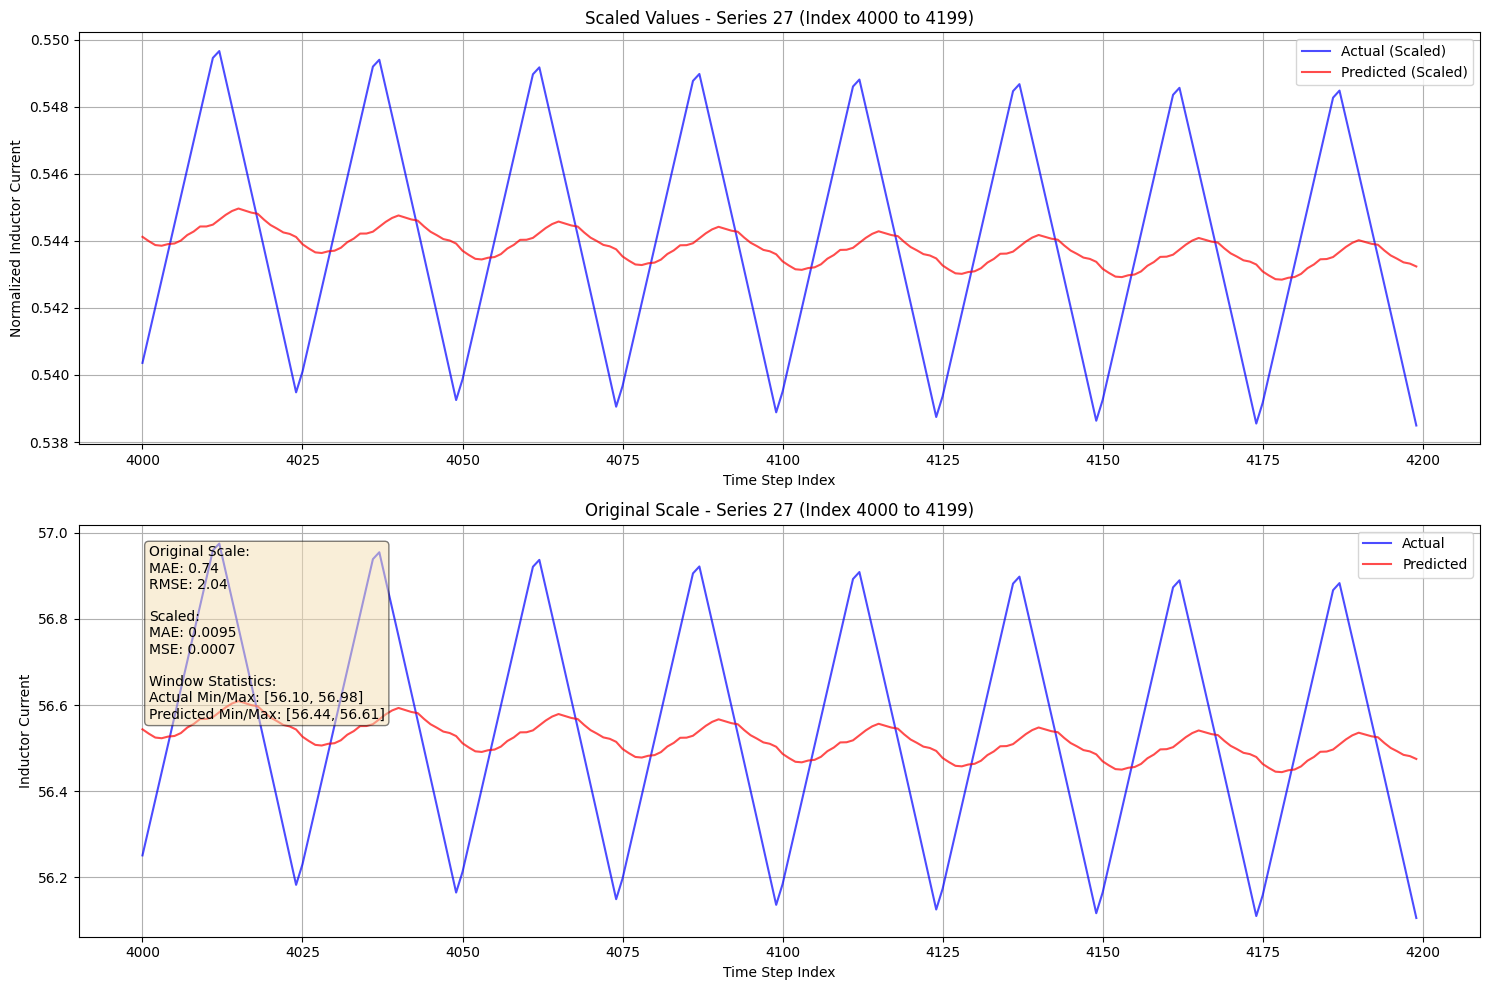


Series 27 Window Statistics (Index 4000 to 4199):
Scaled Values Range:
Actual: [0.538, 0.550]
Predicted: [0.543, 0.545]
Original Values Range:
Actual: [56.105, 56.975]
Predicted: [56.444, 56.609]


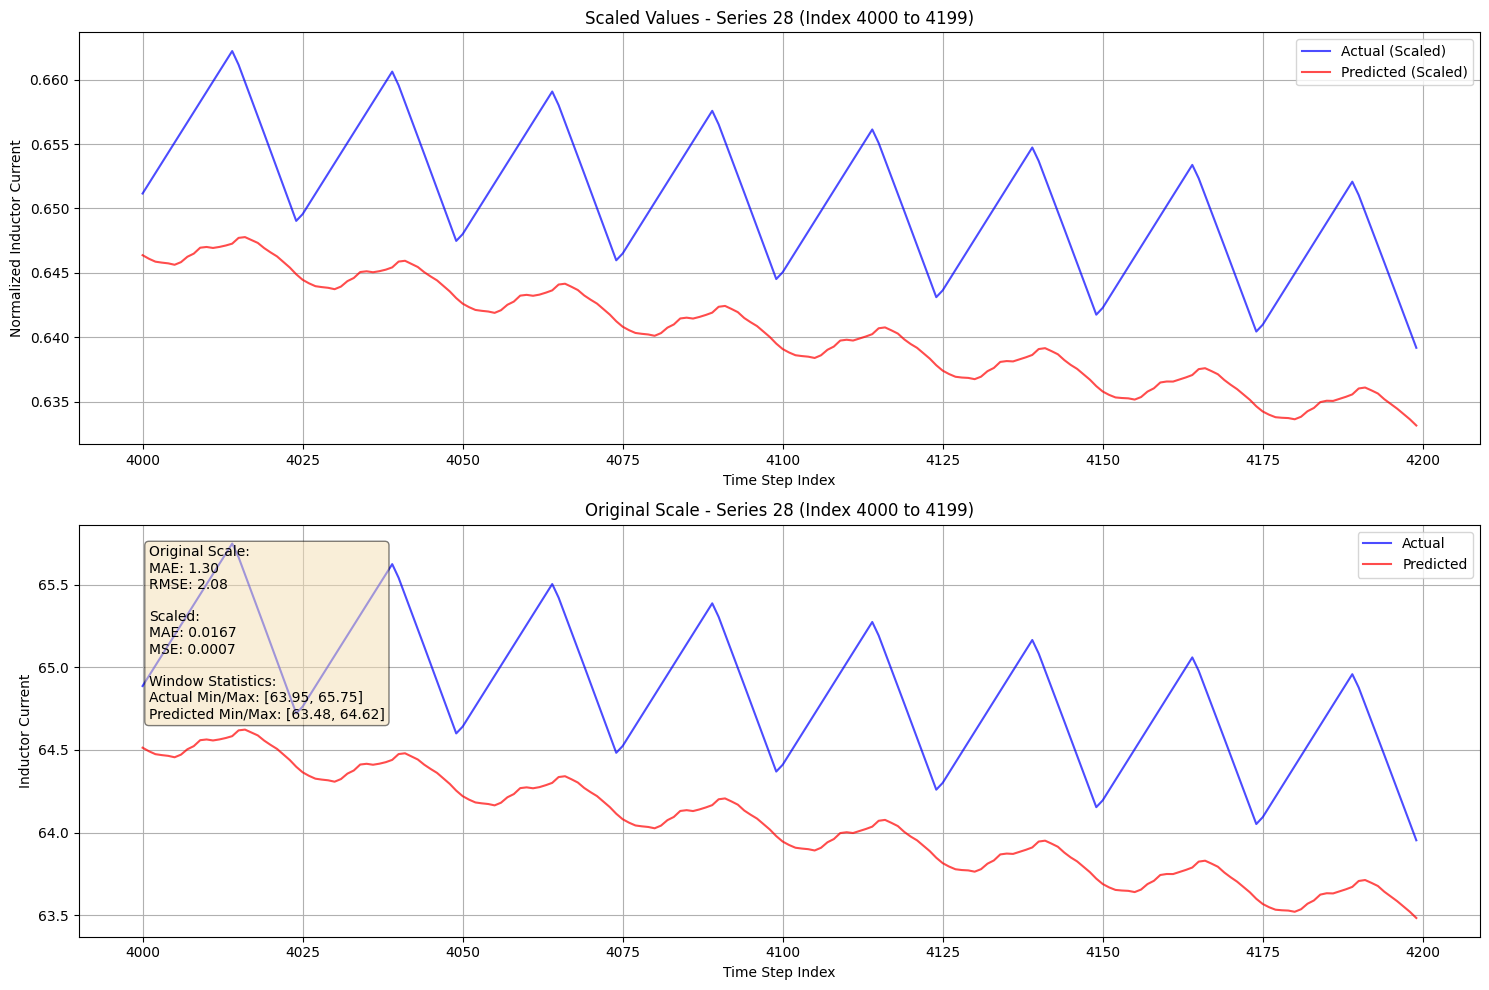


Series 28 Window Statistics (Index 4000 to 4199):
Scaled Values Range:
Actual: [0.639, 0.662]
Predicted: [0.633, 0.648]
Original Values Range:
Actual: [63.953, 65.748]
Predicted: [63.483, 64.622]


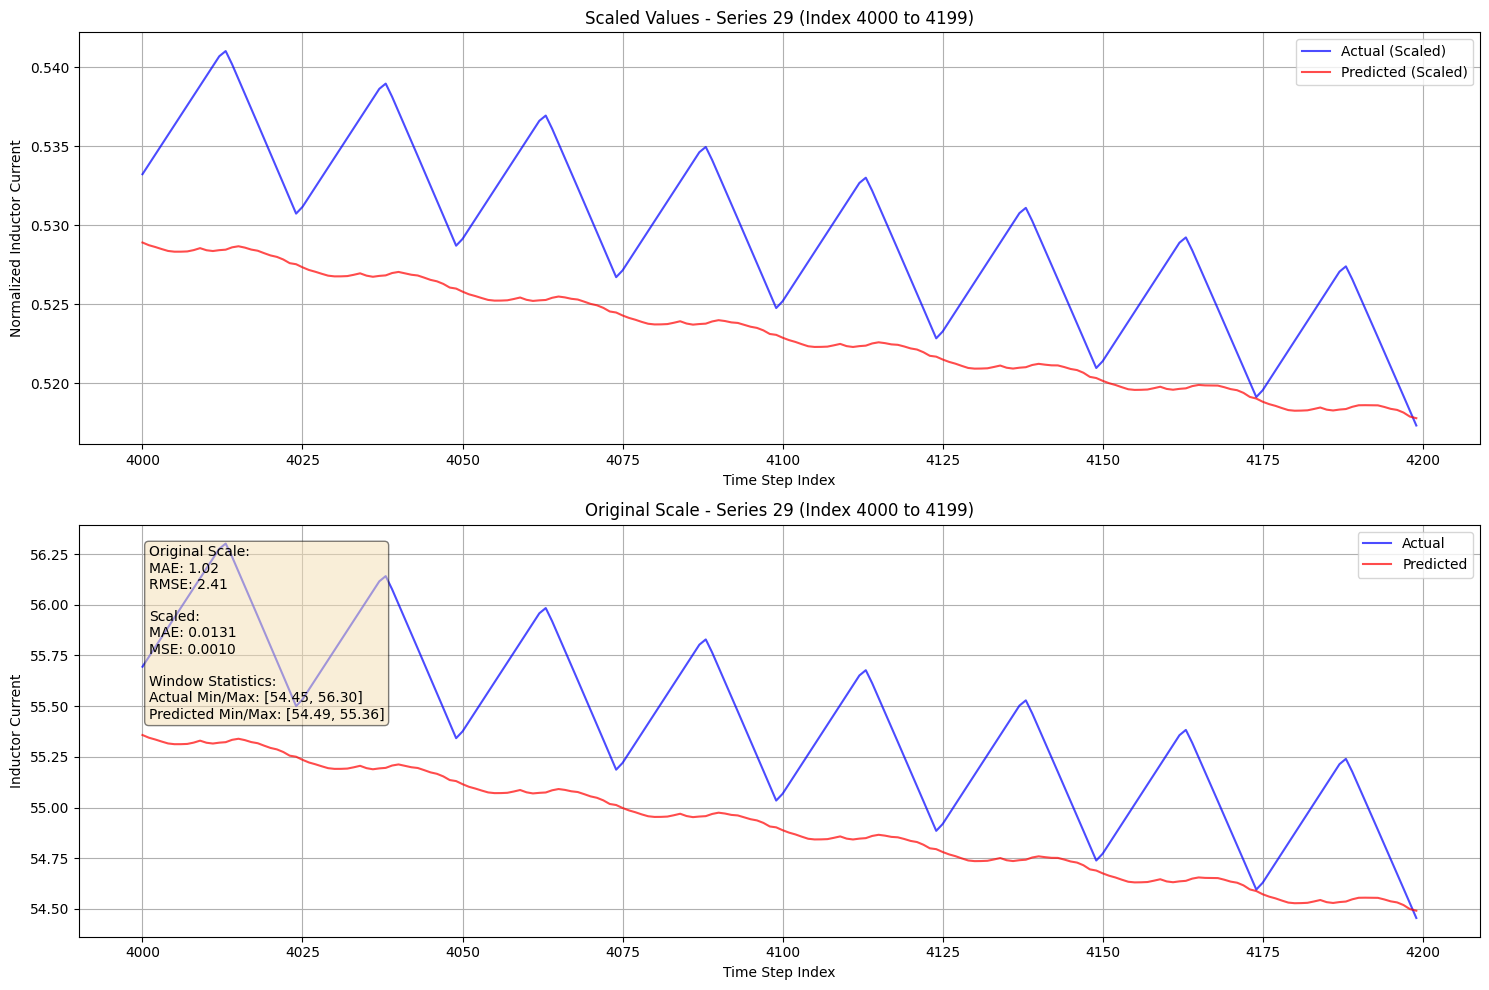


Series 29 Window Statistics (Index 4000 to 4199):
Scaled Values Range:
Actual: [0.517, 0.541]
Predicted: [0.518, 0.529]
Original Values Range:
Actual: [54.455, 56.302]
Predicted: [54.491, 55.358]


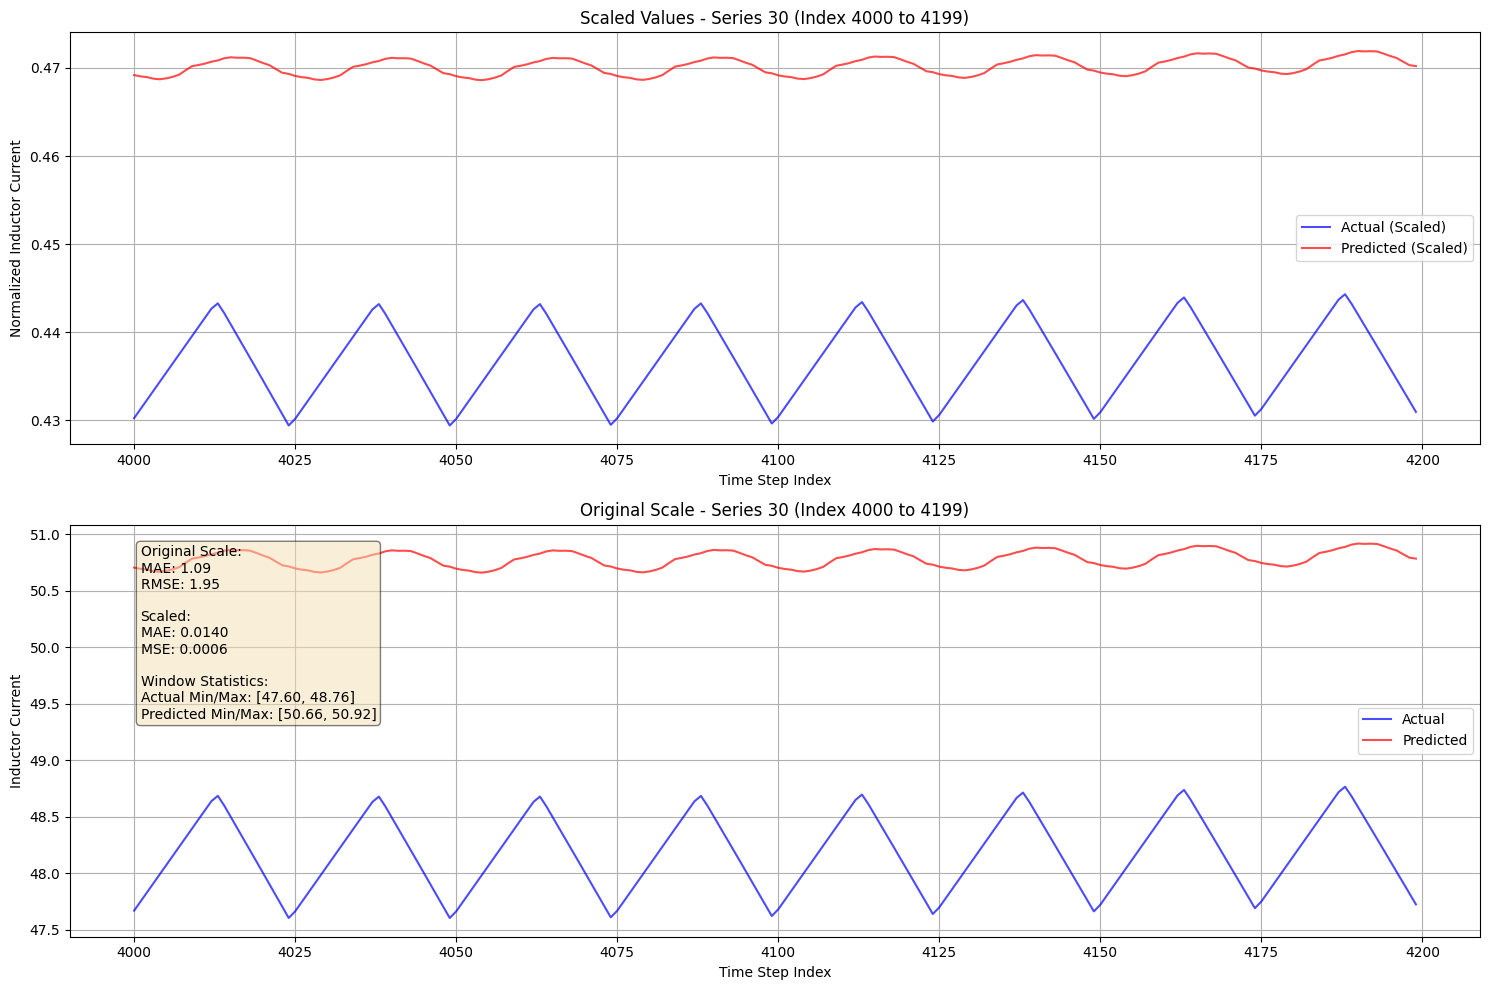


Series 30 Window Statistics (Index 4000 to 4199):
Scaled Values Range:
Actual: [0.429, 0.444]
Predicted: [0.469, 0.472]
Original Values Range:
Actual: [47.603, 48.765]
Predicted: [50.659, 50.916]


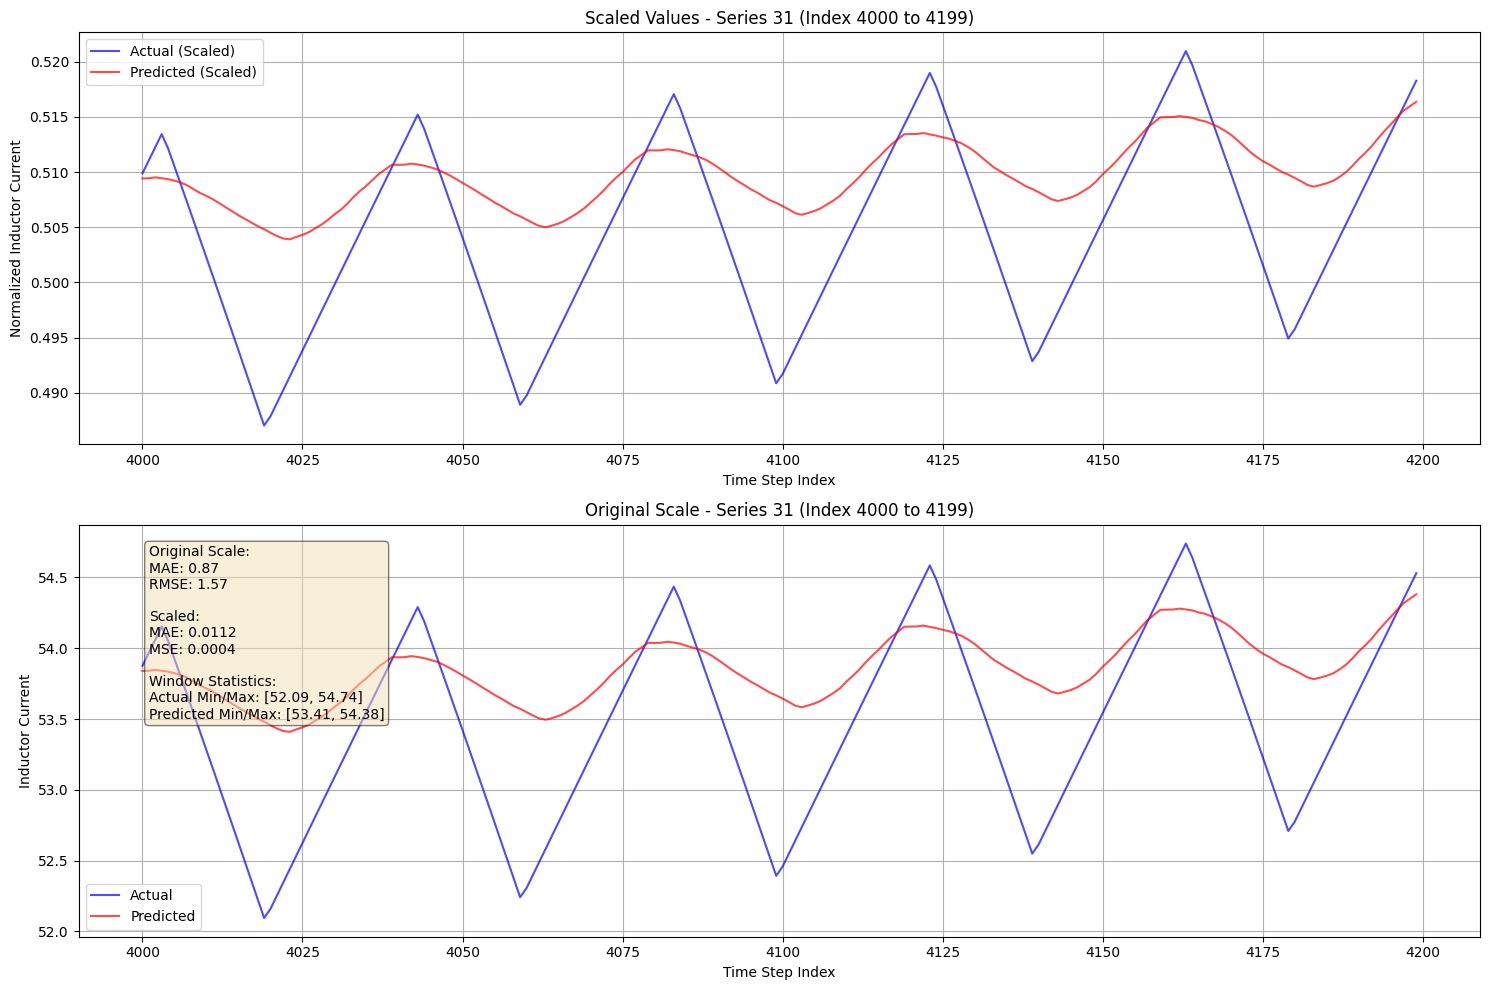


Series 31 Window Statistics (Index 4000 to 4199):
Scaled Values Range:
Actual: [0.487, 0.521]
Predicted: [0.504, 0.516]
Original Values Range:
Actual: [52.095, 54.739]
Predicted: [53.409, 54.381]


In [15]:
# Function to create zoomed-in plots for all test series starting from the 4000th value
def plot_zoomed_series(results_df, scaler_y, start_idx=4000, window_size=200):
    """
    Create zoomed-in plots for all test series showing a window of specified size starting from a specific index

    Parameters:
    -----------
    results_df: DataFrame containing 'Series_ID', 'Actual', 'Predicted', 'Actual_Scaled', 'Predicted_Scaled'
    scaler_y: scaler object used for inverse transformations (not needed if results already contain both scaled and original)
    start_idx: int, starting index for visualization (default=4000)
    window_size: int, number of time steps to visualize (default=200)
    """
    # Get unique series IDs
    unique_series = results_df['Series_ID'].unique()

    # Loop through each series
    for series_id in unique_series:
        # Get data for this series
        series_data = results_df[results_df['Series_ID'] == series_id]

        # Check if series is long enough for requested start index
        if len(series_data) <= start_idx:
            print(f"Warning: Series {series_id} has only {len(series_data)} points, which is less than the requested start index {start_idx}.")
            print(f"Showing the last {min(window_size, len(series_data))} points instead.")
            # If not enough data, show the last window_size points or all available data
            start = max(0, len(series_data) - window_size)
            end = len(series_data)
        else:
            # Ensure we don't exceed the available data
            start = start_idx
            end = min(start_idx + window_size, len(series_data))

        # Get windowed data
        windowed_data = series_data.iloc[start:end].reset_index(drop=True)

        # Create x-axis values showing actual indices
        x_values = np.arange(start, end)

        # Get metrics for this series from the metrics_df
        metrics = metrics_df[metrics_df['Series_ID'] == series_id].iloc[0]

        # Create subplots
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

        # Plot scaled values
        ax1.plot(x_values, windowed_data['Actual_Scaled'].values, label='Actual (Scaled)', color='blue', alpha=0.7)
        ax1.plot(x_values, windowed_data['Predicted_Scaled'].values, label='Predicted (Scaled)', color='red', alpha=0.7)
        ax1.set_title(f'Scaled Values - Series {series_id} (Index {start} to {end-1})')
        ax1.set_xlabel('Time Step Index')
        ax1.set_ylabel('Normalized Inductor Current')
        ax1.grid(True)
        ax1.legend()

        # Plot original values
        ax2.plot(x_values, windowed_data['Actual'].values, label='Actual', color='blue', alpha=0.7)
        ax2.plot(x_values, windowed_data['Predicted'].values, label='Predicted', color='red', alpha=0.7)
        ax2.set_title(f'Original Scale - Series {series_id} (Index {start} to {end-1})')
        ax2.set_xlabel('Time Step Index')
        ax2.set_ylabel('Inductor Current')
        ax2.grid(True)
        ax2.legend()

        # Add metrics text box
        textstr = '\n'.join((
            f'Original Scale:',
            f'MAE: {metrics["MAE"]:.2f}',
            f'RMSE: {metrics["RMSE"]:.2f}',
            f'\nScaled:',
            f'MAE: {metrics["MAE_Scaled"]:.4f}',
            f'MSE: {metrics["MSE_Scaled"]:.4f}',
            f'\nWindow Statistics:',
            f'Actual Min/Max: [{windowed_data["Actual"].min():.2f}, {windowed_data["Actual"].max():.2f}]',
            f'Predicted Min/Max: [{windowed_data["Predicted"].min():.2f}, {windowed_data["Predicted"].max():.2f}]'
        ))
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        ax2.text(0.05, 0.95, textstr, transform=ax2.transAxes,
                fontsize=10, verticalalignment='top', bbox=props)

        plt.tight_layout()
        plt.show()

        # Print statistics for this window
        print(f"\nSeries {series_id} Window Statistics (Index {start} to {end-1}):")
        print("Scaled Values Range:")
        print(f"Actual: [{windowed_data['Actual_Scaled'].min():.3f}, {windowed_data['Actual_Scaled'].max():.3f}]")
        print(f"Predicted: [{windowed_data['Predicted_Scaled'].min():.3f}, {windowed_data['Predicted_Scaled'].max():.3f}]")
        print("Original Values Range:")
        print(f"Actual: [{windowed_data['Actual'].min():.3f}, {windowed_data['Actual'].max():.3f}]")
        print(f"Predicted: [{windowed_data['Predicted'].min():.3f}, {windowed_data['Predicted'].max():.3f}]")

# Call the function to plot zoomed views of all test series
plot_zoomed_series(
    results_df,  # The DataFrame containing all results
    scaler_y,    # The scaler used for transformations
    start_idx=4000,  # Start from the 4000th value
    window_size=200  # Show 200 values
)

Comprehensive Error Metrics by Series:


<ipython-input-16-736ab62b4562>:71: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  error_metrics_df_formatted = error_metrics_df.applymap(format_float)


,Series_ID,MAE,MSE,RMSE,MAPE,Correlation,Actual_Min,Actual_Max,Predicted_Min,Predicted_Max,MAE_Scaled,MSE_Scaled,Count
0,25,5.5960,37.5206,6.1254,16.8045,0.9868,9.7688,63.2049,17.6235,61.4375,0.0718,0.0062,9900
1,26,5.3036,36.4204,6.0349,16.5767,0.9848,12.9483,74.8712,19.1707,73.2216,0.0680,0.0060,9900
2,27,0.7416,4.1582,2.0392,2.6361,0.9866,8.2001,70.3678,17.3794,70.8270,0.0095,0.0007,9900
3,28,1.3020,4.3289,2.0806,3.2600,0.9940,8.2225,81.6291,16.6870,79.0118,0.0167,0.0007,9900
4,29,1.0247,5.8001,2.4083,4.0386,0.9896,6.1780,69.0932,15.4527,68.9370,0.0131,0.0010,9900
5,30,1.0885,3.7950,1.9481,2.8701,0.9928,9.8352,80.3517,18.2406,78.4779,0.0140,0.0006,9900
6,31,0.8742,2.4539,1.5665,1.9906,0.9926,11.9560,84.0680,19.5457,80.7230,0.0112,0.0004,9900
7,ALL SERIES,2.2758,13.4967,3.6738,6.8824,0.9916,6.1780,84.0680,15.4527,80.7230,0.0292,0.0022,69300



Metrics saved to 'series_error_metrics.csv'


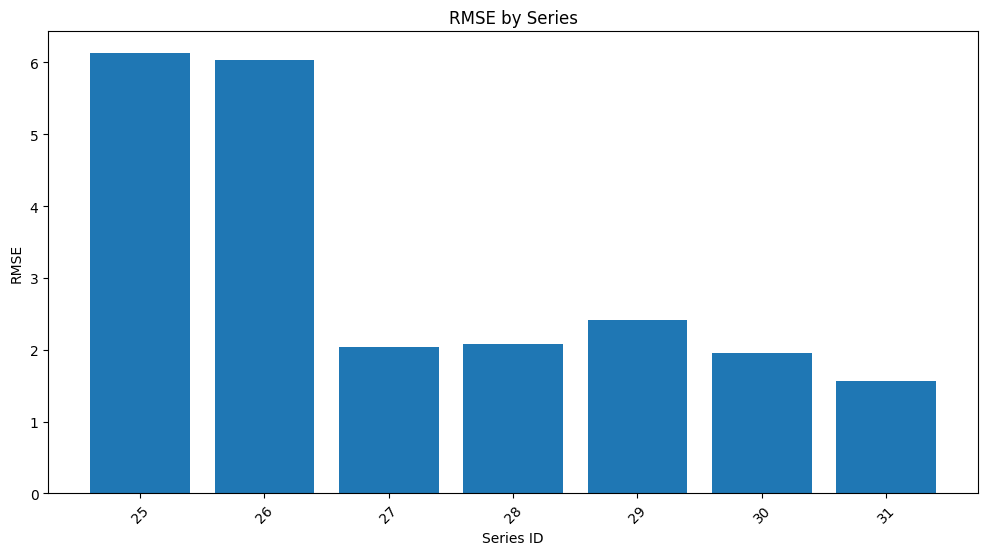

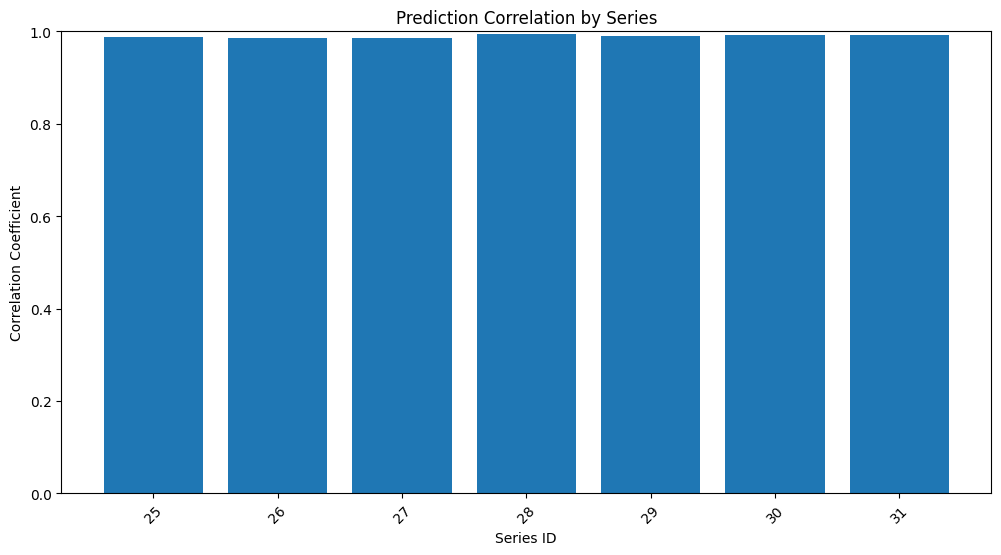

In [16]:
# Create a DataFrame with all series and their error metrics
series_results = []

for series_id in unique_series:
    series_data = results_df[results_df['Series_ID'] == series_id]
    actual = series_data['Actual']
    predicted = series_data['Predicted']
    actual_scaled = series_data['Actual_Scaled']
    predicted_scaled = series_data['Predicted_Scaled']

    # Calculate metrics
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100  # Mean Absolute Percentage Error

    mae_scaled = mean_absolute_error(actual_scaled, predicted_scaled)
    mse_scaled = mean_squared_error(actual_scaled, predicted_scaled)

    # Calculate correlation
    correlation = np.corrcoef(actual, predicted)[0, 1]

    # Get value ranges
    actual_min, actual_max = actual.min(), actual.max()
    pred_min, pred_max = predicted.min(), predicted.max()

    series_results.append({
        'Series_ID': series_id,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'Correlation': correlation,
        'Actual_Min': actual_min,
        'Actual_Max': actual_max,
        'Predicted_Min': pred_min,
        'Predicted_Max': pred_max,
        'MAE_Scaled': mae_scaled,
        'MSE_Scaled': mse_scaled,
        'Count': len(series_data)  # Number of observations in this series
    })

# Create the DataFrame
error_metrics_df = pd.DataFrame(series_results)

# Add overall metrics as the last row
overall_metrics = {
    'Series_ID': 'ALL SERIES',
    'MAE': mean_absolute_error(results_df['Actual'], results_df['Predicted']),
    'MSE': mean_squared_error(results_df['Actual'], results_df['Predicted']),
    'RMSE': np.sqrt(mean_squared_error(results_df['Actual'], results_df['Predicted'])),
    'MAPE': np.mean(np.abs((results_df['Actual'] - results_df['Predicted']) / results_df['Actual'])) * 100,
    'Correlation': np.corrcoef(results_df['Actual'], results_df['Predicted'])[0, 1],
    'Actual_Min': results_df['Actual'].min(),
    'Actual_Max': results_df['Actual'].max(),
    'Predicted_Min': results_df['Predicted'].min(),
    'Predicted_Max': results_df['Predicted'].max(),
    'MAE_Scaled': mean_absolute_error(results_df['Actual_Scaled'], results_df['Predicted_Scaled']),
    'MSE_Scaled': mean_squared_error(results_df['Actual_Scaled'], results_df['Predicted_Scaled']),
    'Count': len(results_df)
}

error_metrics_df = pd.concat([error_metrics_df, pd.DataFrame([overall_metrics])], ignore_index=True)

# Format the DataFrame for better display
def format_float(x):
    if isinstance(x, (float, np.floating)):
        return f"{x:.4f}"
    return x

error_metrics_df_formatted = error_metrics_df.applymap(format_float)

# Display the DataFrame
print("Comprehensive Error Metrics by Series:")
display(error_metrics_df_formatted)

# Save to CSV
error_metrics_df.to_csv('series_error_metrics.csv', index=False)
print("\nMetrics saved to 'series_error_metrics.csv'")

# Additional visualizations
plt.figure(figsize=(12, 6))
plt.bar(error_metrics_df[:-1]['Series_ID'].astype(str), error_metrics_df[:-1]['RMSE'])
plt.title('RMSE by Series')
plt.xlabel('Series ID')
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(error_metrics_df[:-1]['Series_ID'].astype(str), error_metrics_df[:-1]['Correlation'])
plt.title('Prediction Correlation by Series')
plt.xlabel('Series ID')
plt.ylabel('Correlation Coefficient')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()